## load model and dataset


/home/local/ASUAD/asing651/.conda/envs/rapids310/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/local/ASUAD/asing651/.conda/envs/rapids310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/local/ASUAD/asing651/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 115MB/s] 


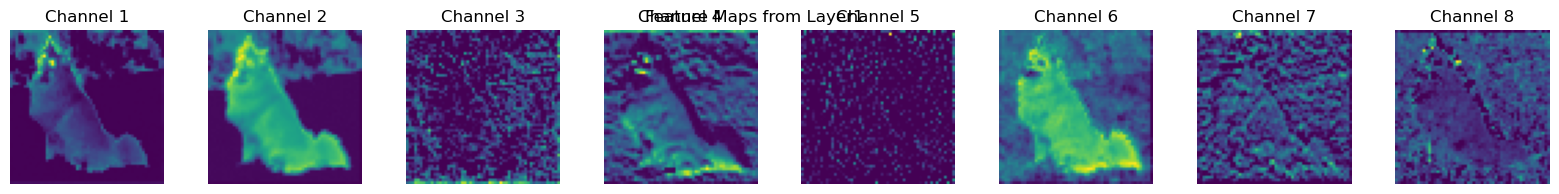

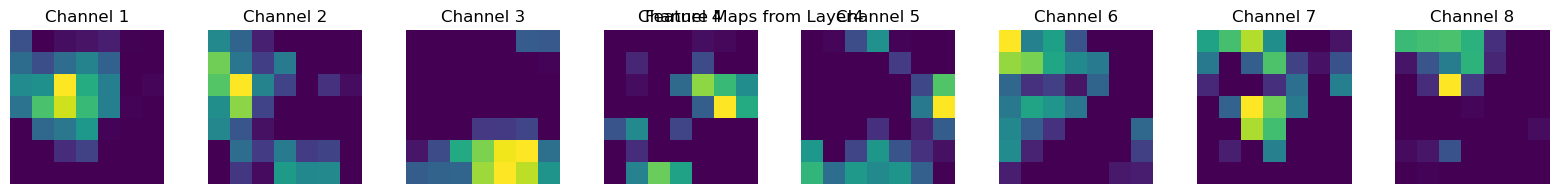

Layer1 feature map shape: torch.Size([1, 256, 56, 56])
Layer4 feature map shape: torch.Size([1, 2048, 7, 7])


In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import urllib.request

# Step 1: Load a sample image from the web
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
image_path = "dog.jpg"
urllib.request.urlretrieve(url, image_path)
image = Image.open(image_path).convert("RGB")

# Step 2: Preprocess the image
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
input_tensor = preprocess(image).unsqueeze(0)  # Shape: [1, 3, 224, 224]

# Step 3: Load pre-trained ResNet-50
model = models.resnet50(pretrained=True)
model.eval()

# Step 4: Hook to capture feature maps
feature_maps = []
def hook(module, input, output):
    feature_maps.append(output.detach())

# Register hooks on specific layers (e.g., layer1, layer4)
model.layer1.register_forward_hook(hook)
model.layer4.register_forward_hook(hook)

# Step 5: Pass the image through the model
with torch.no_grad():
    _ = model(input_tensor)

# Step 6: Visualize feature maps
def visualize_feature_map(feature_map, layer_name, num_channels=8):
    feature_map = feature_map.squeeze(0)  # Remove batch dimension
    fig, axes = plt.subplots(1, num_channels, figsize=(20, 2))
    for i in range(num_channels):
        # Normalize the feature map for visualization
        fmap = feature_map[i].cpu().numpy()
        fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
        axes[i].imshow(fmap, cmap="viridis")
        axes[i].axis("off")
        axes[i].set_title(f"Channel {i+1}")
    plt.suptitle(f"Feature Maps from {layer_name}")
    plt.show()

# Visualize feature maps from layer1 and layer4
visualize_feature_map(feature_maps[0], "Layer1")
visualize_feature_map(feature_maps[1], "Layer4")

# Step 7: Print feature map shapes
print(f"Layer1 feature map shape: {feature_maps[0].shape}")
print(f"Layer4 feature map shape: {feature_maps[1].shape}")

In [1]:
from models.densenet import DenseNet3
from models.resnet import ResNet34, ResNet18, ResNet50
import torch
from collections import OrderedDict
from torchvision.transforms import transforms
import torchvision
from torch.utils.data import DataLoader
import numpy as np
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from joblib import load ,dump
import io,pickle
device = "cuda:1"

input_size = (32, 32) 
m_name = "densenet3"
# m_name = "resnet18"
id_name = "cifar10"
num_classes = 10
model = DenseNet3(100,num_classes).to(device)

# model = ResNet18(100).to(device)
checkpoint = torch.load(f"./pre_trained/{m_name}_{id_name}.pth")
new_state_dict = OrderedDict()
for k,v in checkpoint.items():
    new_key = k.replace('module.','')
    new_state_dict[new_key] = v
model.load_state_dict(new_state_dict)



"""
ID data -> Cifar 10
Profiling(mean and covariance is done on Cifar 10)
"""
data_path = "./data"

transform_test = transforms.Compose([
    transforms.Resize(input_size), 
    transforms.ToTensor(),   
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))   
])
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',   
    train=False,     
    download=True,   
    transform=transform_test   
)

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',   
    train=True,     
    download=True,   
    transform=transform_test   
)
batch_size =64
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,    
    shuffle=False,    
    num_workers=2     
)
test_loader_fast = DataLoader(
    dataset=test_dataset,
    batch_size=64,   
    shuffle=False,    
    num_workers=2,     
)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=100,    
    shuffle=False,    
    num_workers=2     
)

# Create test datasets
fashion_test_dataset = torchvision.datasets.FashionMNIST(root=data_path, train=False, download=True, transform=transform_test)
svhn_test_dataset = torchvision.datasets.SVHN(root=data_path, split='test', download=True, transform=transform_test)
isun_test_dataset = torchvision.datasets.ImageFolder(root=f"{data_path}/isun", transform=transform_test)
lsun_test_dataset = torchvision.datasets.ImageFolder(root=f"{data_path}/lsun_resize", transform=transform_test)
cifar100_test_dataset = torchvision.datasets.CIFAR100(root=data_path, train=False, download=True, transform=transform_test)
# tinyimagenet_test_dataset = torchvision.datasets.ImageFolder(root=f"{data_path}/tiny-imagenet-200/test", transform=transform_test)
dtd_test_dataset = torchvision.datasets.DTD(root="./data", split="test", download=True, transform=transform_test)
# places365_test_dataset = torchvision.datasets.ImageFolder(root=f"{data_path}/places365", transform=transform_test)

# Create test data loaders
 # Set your batch size here
svhn_test_loader = DataLoader(svhn_test_dataset, batch_size=batch_size, shuffle=False)
isun_test_loader = DataLoader(isun_test_dataset, batch_size=batch_size, shuffle=False)
lsun_test_loader = DataLoader(lsun_test_dataset, batch_size=batch_size, shuffle=False)
fashion_test_loader = DataLoader(fashion_test_dataset,batch_size=batch_size, shuffle=False)
cifar100_test_loader = DataLoader(dataset=cifar100_test_dataset,batch_size=batch_size,shuffle=False)
dtd_test_loader =DataLoader(dataset=dtd_test_dataset,batch_size=batch_size,shuffle=False)
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------
autoAttack_data = torch.load(f'./adv_samples/{m_name}_{id_name}_autoattack.pt',weights_only= False)
# adv_samples/resnet34_cifar10_autoattack.pt
data_list, label_list = zip(*autoAttack_data)
inputs_tensor = torch.stack([torch.from_numpy(data).float() for data in data_list])
labels_tensor = torch.tensor(label_list, dtype=torch.long)

AA_dataset = TensorDataset(inputs_tensor, labels_tensor)
Autoattack_test_loader = DataLoader(AA_dataset, batch_size=batch_size, shuffle=False)
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------
fgsm_data = torch.load(f'./adv_samples/{m_name}_{id_name}_fgsm.pt',weights_only= False)
data_list, label_list = zip(*fgsm_data)
inputs_tensor = torch.stack([torch.from_numpy(data).float() for data in data_list])
labels_tensor = torch.tensor(label_list, dtype=torch.long)
fsgm_dataset = TensorDataset(inputs_tensor, labels_tensor)
fgsm_test_loader = DataLoader(fsgm_dataset, batch_size=batch_size, shuffle=False)
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------
pgd_data = torch.load(f'./adv_samples/{m_name}_{id_name}_pgd.pt',weights_only= False)
data_list, label_list = zip(*pgd_data)
inputs_tensor = torch.stack([torch.from_numpy(data).float() for data in data_list])
labels_tensor = torch.tensor(label_list, dtype=torch.long)
pgd_dataset = TensorDataset(inputs_tensor, labels_tensor)
pgd_test_loader = DataLoader(pgd_dataset, batch_size=batch_size, shuffle=False)
#=======================================================================================================================================================================
cw_data = torch.load(f'./adv_samples/{m_name}_{id_name}_cw.pt',weights_only= False)
data_list, label_list = zip(*cw_data)
inputs_tensor = torch.stack([torch.from_numpy(data).float() for data in data_list])
labels_tensor = torch.tensor(label_list, dtype=torch.long)
cw_dataset = TensorDataset(inputs_tensor, labels_tensor)
cw_test_loader = DataLoader(cw_dataset, batch_size=batch_size, shuffle=False)
#------------------------------------------------------------------------------------------------------------------------------------------------------------
deepfool_data = torch.load(f'./adv_samples/{m_name}_{id_name}_deepfool.pt',weights_only= False)
data_list, label_list = zip(*deepfool_data)
inputs_tensor = torch.stack([torch.from_numpy(data).float() for data in data_list])
labels_tensor = torch.tensor(label_list, dtype=torch.long)
deepfool_dataset = TensorDataset(inputs_tensor, labels_tensor)
deepfool_test_loader = DataLoader(deepfool_dataset, batch_size=batch_size, shuffle=False)
#------------------------------------------------------------------------------------------------------------------------------------------------------------







## mean and precision evaluations 

In [54]:
import torch
import cupy as cp
from collections import defaultdict
import pickle

def nested_defaultdict():
    return defaultdict(create_default_dict)

def create_default_dict():
    return {'n': 0, 'mean': None, 'precision': None}

stats = defaultdict(nested_defaultdict)


# Assuming test_loader is your data loader
for images, labels in train_loader:
    images = images.to(device)
    
    # Forward pass to get features
    features = list(model.intermediate_forward(images, layer_index=-1))
    
    # Process features
    for i in range(len(features)):
        features[i] = features[i].view(features[i].size(0), features[i].size(1), -1)
        features[i] = torch.mean(features[i].data, 2)  # Global average pooling
    
    # Convert features to CuPy arrays for GPU computation
    features = [cp.asarray(f.cpu()) for f in features]
    labels = cp.asarray(labels.cpu())
    
    # Group features by class
    unique_classes = cp.unique(labels)
    for class_id in unique_classes:
        # Convert class_id to a hashable type (int)
        class_id = int(class_id)
        
        # Get indices of samples belonging to this class
        class_indices = cp.where(labels == class_id)[0]
        
        # Get features for this class
        class_features = [f[class_indices] for f in features]
        
        # Update rolling statistics for each feature per class
        for feature_idx, feature_batch in enumerate(class_features):
            m = feature_batch.shape[0]  # Number of samples in this class for this batch
            if m == 0:
                continue  # Skip if no samples for this class in this batch
            
            # Compute batch mean and covariance
            batch_mean = cp.mean(feature_batch, axis=0)
            centered_batch = feature_batch - batch_mean
            batch_cov = cp.dot(centered_batch.T, centered_batch) / m
            
            # Get current global stats for this feature and class
            current_stats = stats[feature_idx][class_id]
            n = current_stats['n']
            mean = current_stats['mean']
            precision = current_stats['precision']
            
            if mean is None:
                # First batch for this feature and class
                new_mean = batch_mean
                new_cov = batch_cov
            else:
                # Update global mean
                new_mean = (n * mean + m * batch_mean) / (n + m)
                
                # Update global covariance
                term1 = n * cp.linalg.inv(precision) if precision is not None else cp.zeros_like(batch_cov)
                term2 = m * batch_cov
                term3 = n * cp.outer(mean - new_mean, mean - new_mean)
                term4 = m * cp.outer(batch_mean - new_mean, batch_mean - new_mean)
                new_cov = (term1 + term2 + term3 + term4) / (n + m)
            
            # Compute the precision matrix (inverse of the covariance matrix)
            try:
                new_precision = cp.linalg.inv(new_cov)
            except cp.linalg.LinAlgError:
                # Handle singular matrix case (e.g., add a small regularization term)
                regularization = 1e-6 * cp.eye(new_cov.shape[0])
                new_precision = cp.linalg.inv(new_cov + regularization)

            if cp.any(cp.isnan(new_precision)):
                regularization = 1e-12 * cp.eye(new_cov.shape[0])
                new_precision = cp.linalg.inv(new_cov + regularization)
            if cp.any(cp.isnan(new_precision)):
                raise ValueError("NaN values detected in precision matrix.")
            
            # Update global stats
            stats[feature_idx][class_id]['n'] = n + m
            stats[feature_idx][class_id]['mean'] = new_mean
            stats[feature_idx][class_id]['precision'] = new_precision

# Print the results for each feature and class
for feature_idx, feature_stats in stats.items():
    for class_id, class_stats in feature_stats.items():
        print(f"Feature {feature_idx}, Class {class_id}:")
        print("Rolling Mean:", class_stats['mean'])
        print("Precision Matrix Shape:", class_stats['precision'].shape)
        print()
with open('./stats.pkl', 'wb') as f:
    pickle.dump(stats, f)

Feature 0, Class 0:
Rolling Mean: [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.8850732e-01
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.4759319e-01
 2.5271410e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 3.8570791e-02
 0.0000000e+00 0.0000000e+00 3.8171428e-01 0.0000000e+00 1.1131328e-01
 0.0000000e+00 4.3279374e-07 0.0000000e+00 5.5028636e-02 0.0000000e+00
 0.0000000e+00 4.1840374e-02 0.0000000e+00 1.0409119e-01 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1663350e-02
 1.4442332e-01 2.1055710e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 5.0928307e-01
 0.0000000e+00 1.9721161e-01 5.0110996e-01 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.0029953e-01
 2.0165816e-01 0.0000000e+00 0.0000000e+00 2.1462487e-02 0.0000000e+00
 8.4062032e-02 0.0000000e+00 0.0000000e+00 0.0000000e+00]
Precision Matrix Shape: (64, 64)

Feature 0, Class 1:
Ro

## Load the stats 

In [55]:
with open('stats.pkl', 'rb') as f:
    stats = pickle.load(f)


In [53]:
stats[0]

defaultdict(<function __main__.create_default_dict()>,
            {0: {'n': 5000,
              'mean': array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
                     1.8850732e-01, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
                     0.0000000e+00, 2.4759319e-01, 2.5271410e-01, 0.0000000e+00,
                     0.0000000e+00, 0.0000000e+00, 3.8570791e-02, 0.0000000e+00,
                     0.0000000e+00, 3.8171428e-01, 0.0000000e+00, 1.1131328e-01,
                     0.0000000e+00, 4.3279374e-07, 0.0000000e+00, 5.5028636e-02,
                     0.0000000e+00, 0.0000000e+00, 4.1840374e-02, 0.0000000e+00,
                     1.0409119e-01, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
                     0.0000000e+00, 0.0000000e+00, 7.1663350e-02, 1.4442332e-01,
                     2.1055710e-01, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
                     0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
                  

## 

In [ ]:
mahalanobis_distances = defaultdict(lambda: defaultdict(list))
for images, labels in pgd_test_loader:
    images = images.to(device)
    features = list(model.intermediate_forward(images, layer_index=-1))

 # Process features
    for i in range(len(features)):
        features[i] = features[i].view(features[i].size(0), features[i].size(1), -1)
        features[i] = torch.mean(features[i].data, 2)  # Global average pooling

    features = [cp.asarray(f.cpu()) for f in features]
    labels = cp.asarray(labels.cpu())

    unique_classes = cp.unique(labels)
    for class_id in unique_classes:
        # Convert class_id to a hashable type (int)
        class_id = int(class_id)

        class_features = features
        
        # Calculate Mahalanobis distance for each feature
        for feature_idx, feature_batch in enumerate(class_features):
            # print(feature_batch, feature_idx)
            if feature_batch.shape[0] == 0:
                continue  # Skip if no samples for this class in this batch

            if feature_idx in stats and class_id in stats[feature_idx]:
                mean = stats[feature_idx][class_id]['mean']
                precision = stats[feature_idx][class_id]['precision']
                
                # Calculate Mahalanobis distance
                centered_batch = feature_batch - mean
                mahalanobis_dist = cp.sum(centered_batch @ precision * centered_batch, axis=1)
                
                # Store the distances
                mahalanobis_distances[feature_idx][class_id].extend(mahalanobis_dist.tolist())
    print(mahalanobis_distances.keys())
    
    break

[[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.9717784e-01
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.4936170e-01
  1.9975865e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 9.0667769e-02
  0.0000000e+00 0.0000000e+00 2.8802487e-01 0.0000000e+00 5.5868790e-02
  0.0000000e+00 3.8206355e-07 0.0000000e+00 4.4048227e-02 0.0000000e+00
  0.0000000e+00 9.0801343e-02 0.0000000e+00 8.9477107e-02 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.3454961e-02
  2.1233866e-01 2.1909183e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 4.7784457e-01
  0.0000000e+00 1.9626698e-01 4.9049136e-01 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.1637326e-01
  2.5533122e-01 0.0000000e+00 0.0000000e+00 2.3671921e-02 0.0000000e+00
  1.1939583e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00]] 0
[[0.12930346 0.05766295 0.13847327 0.05932287 0.16543666 0.10294724
  0.14

## plot the embedding/features of one class


/home/local/ASUAD/asing651/.conda/envs/rapids_env/lib/python3.10/site-packages/cuml/internals/api_decorators.py:382: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return init_func(self, *args, **filtered_kwargs)


[W] [15:14:39.053334] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
Shape of X_embedded: (50000, 2)


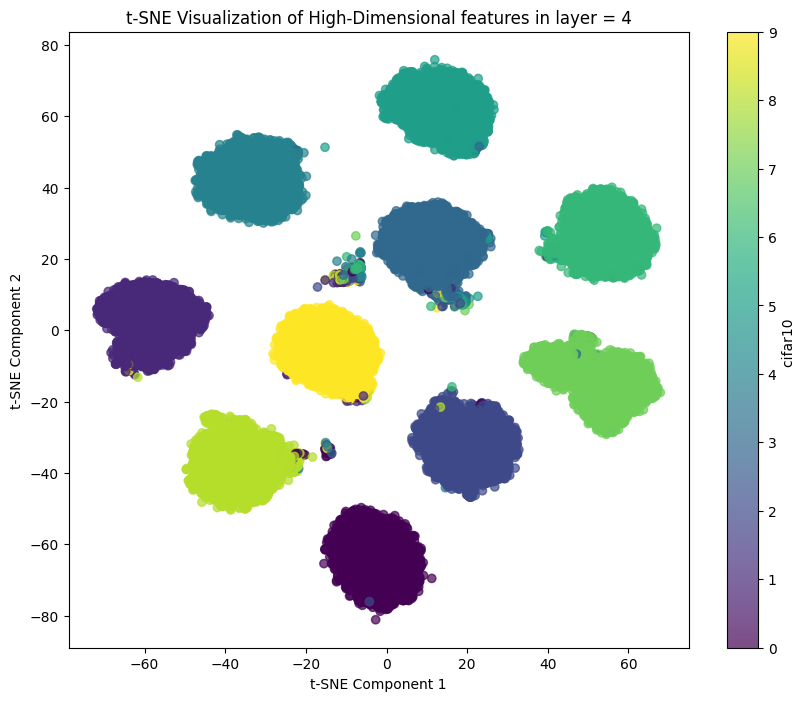

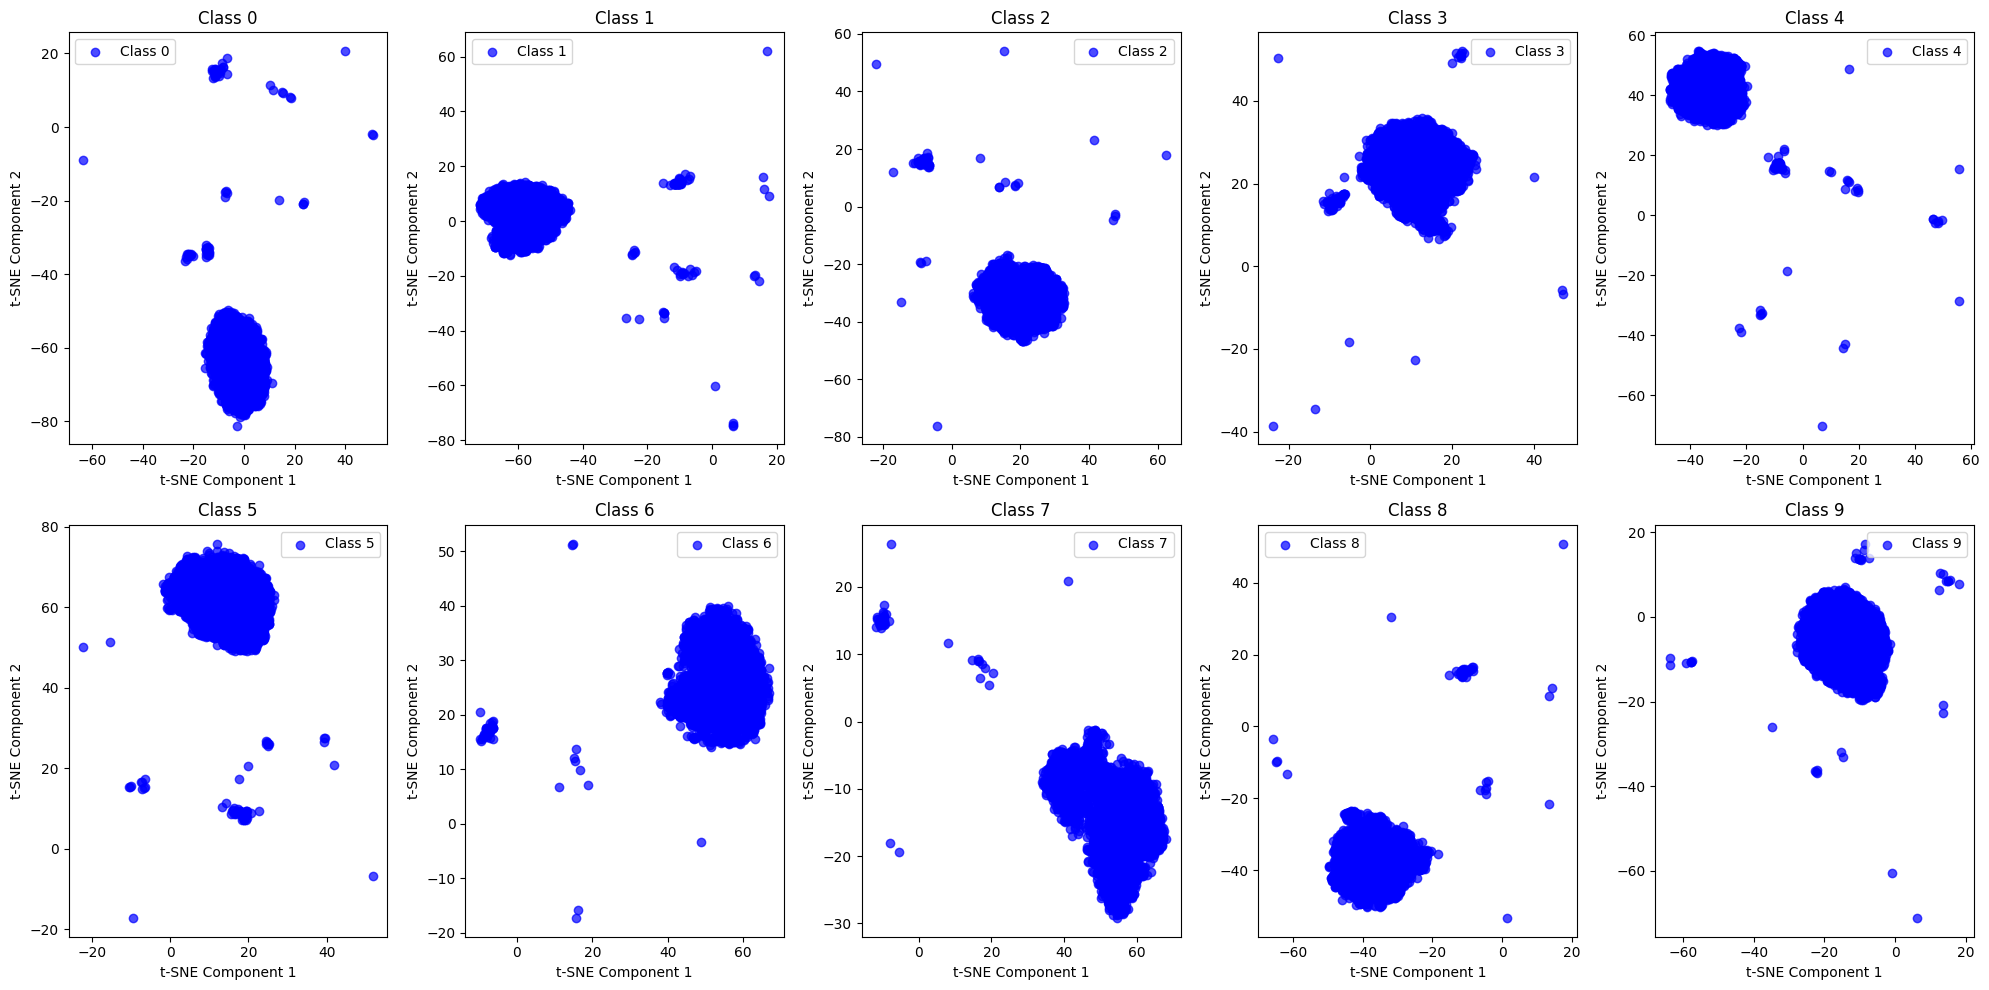

In [3]:
import cudf
import numpy as np
import torch
from cuml.manifold import TSNE
import matplotlib.pyplot as plt

# Initialize lists
features_all = []
labels_all = []

index = 4

# Feature extraction
for images, labels in train_loader:
    images = images.to(device)
    
    features_train = list(model.intermediate_forward(images, layer_index=index))
    for i in range(len(features_train)):
        features_train[i] = features_train[i].view(features_train[i].size(0), features_train[i].size(1), -1)
        features_train[i] = torch.mean(features_train[i].data, 2)  # Global average pooling
    features_all.extend(features_train)  # Append features for the batch
    labels_all.extend(labels.tolist())  # Append labels for the batch



features_tensor = torch.stack(features_all)
features_tensor = features_tensor.reshape(features_tensor.shape[0], -1)

if features_tensor.is_cuda:
    features_array = features_tensor.cpu().numpy()
else:
    features_array = features_tensor.numpy()
gdf = cudf.DataFrame(features_array)

# for OPgd
# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=5000)
X_embedded = tsne.fit_transform(gdf)

# Debug step: Check shape of t-SNE output
print(f"Shape of X_embedded: {X_embedded.shape}")

# Debug step: Ensure lengths match before plotting
assert len(labels_all) == X_embedded.shape[0], "Mismatch between labels and t-SNE output."
labels_all = np.array(labels_all)

# Convert X_embedded (from cudf) back to numpy for compatibility with matplotlib
X_embedded = X_embedded.to_pandas().to_numpy()
# Plot the t-SNE visualization
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels_all, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='cifar10 ')
plt.title(f't-SNE Visualization of High-Dimensional features in layer = {index}')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()


import matplotlib.pyplot as plt
import numpy as np

# Number of classes to plot
num_classes = 10

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 10))  # Adjust rows and columns as needed

for target_class in range(num_classes):
    # Filter the data for the target class
    class_mask = labels_all == target_class
    X_embedded_filtered = X_embedded[class_mask]
    
    # Get the corresponding axis for the subplot
    ax = axes[target_class // 5, target_class % 5]
    
    # Plot the t-SNE visualization for the specific class
    ax.scatter(X_embedded_filtered[:, 0], X_embedded_filtered[:, 1], 
               c='blue', alpha=0.7, label=f'Class {target_class}')
    ax.set_title(f'Class {target_class}')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


## make the plots similarly for different  attacks

 Eval the pgd dataset!

In [11]:
# # Set the model to evaluation mode
# model.eval()

# # Initialize variables to track correct predictions and total samples
# correct = 0
# total = 0
# pred = {}
# # Disable gradient calculation
# with torch.no_grad():
#     for images, labels in pgd_test_loader:
#         # Move images and labels to the appropriate device (e.g., GPU)
#         images = images.to(device)
#         labels = labels.to(device)
        
#         # Forward pass: get model predictions
#         outputs = model(images)
        
#         # Get the predicted class (the class with the highest probability)
#         _, predicted = torch.max(outputs, 1)
#         p= predicted.item()
#         if p in pred:
#             pred[p] +=1
#         else:
#             pred[p] = 1
#         # Update total and correct counts
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()

# # Calculate accuracy
# accuracy = 100 * correct / total
# print(f'Accuracy on PGD Test Loader: {accuracy:.2f}%')

Accuracy on PGD Test Loader: 26.38%


/home/local/ASUAD/asing651/.conda/envs/rapids_env/lib/python3.10/site-packages/cuml/internals/api_decorators.py:382: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return init_func(self, *args, **filtered_kwargs)


[W] [20:27:53.765545] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
Shape of X_embedded: (10000, 2)


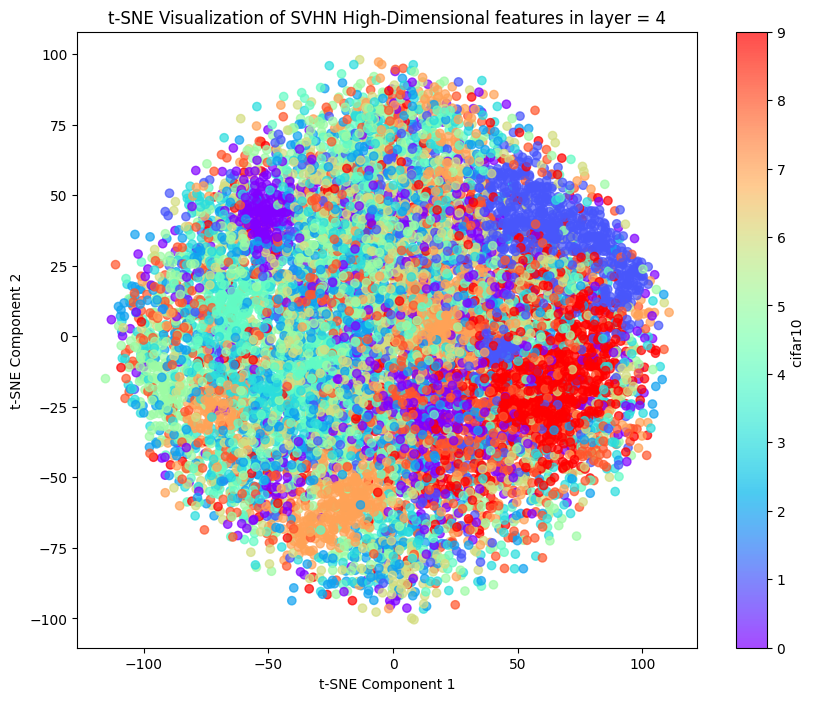

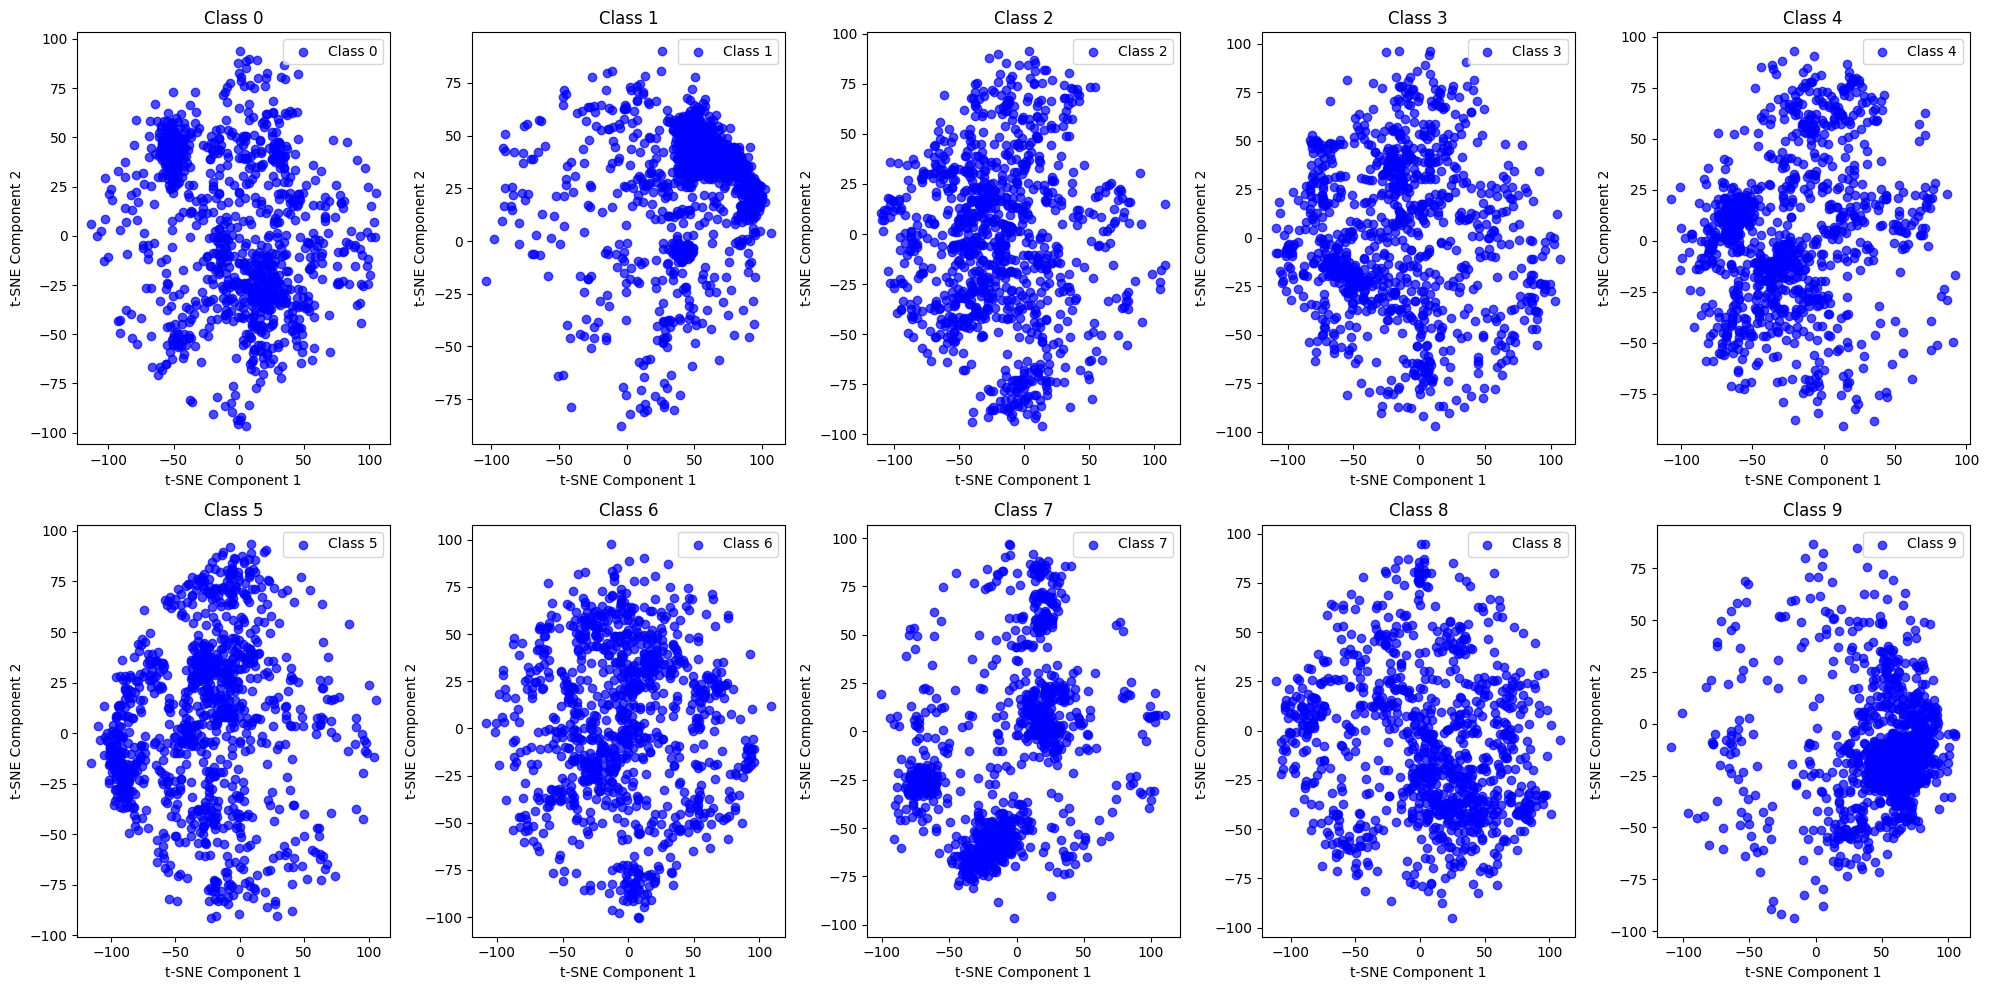

In [ ]:
import cudf
import numpy as np
import torch
from cuml.manifold import TSNE
import matplotlib.pyplot as plt


features_all = []
labels_all = []

index = 4

 
for images, labels in test_loader:
    images = images.to(device)
    features_train = list(model.intermediate_forward(images, layer_index=index))
    for i in range(len(features_train)):
        features_train[i] = features_train[i].view(features_train[i].size(0), features_train[i].size(1), -1)
        features_train[i] = torch.mean(features_train[i].data, 2)   
    features_all.extend(features_train)   
    labels_all.extend(labels.tolist()) 



features_tensor = torch.stack(features_all)
features_tensor = features_tensor.reshape(features_tensor.shape[0], -1)

if features_tensor.is_cuda:
    features_array = features_tensor.cpu().numpy()
else:
    features_array = features_tensor.numpy()
gdf = cudf.DataFrame(features_array)

 
# tsne = TSNE(n_components=2, random_state=42, perplexity=1000, n_iter=5000)
tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=5000)
# tsne = TSNE(n_components=2, perplexity=500, learning_rate=200,auto_iter=True,early_exaggeration=12, init='random', random_state=42)
X_embedded = tsne.fit_transform(gdf)
 
print(f"Shape of X_embedded: {X_embedded.shape}")
 
assert len(labels_all) == X_embedded.shape[0], "Mismatch between labels and t-SNE output."
labels_all = np.array(labels_all)
 
X_embedded = X_embedded.to_pandas().to_numpy()
 
df = cudf.DataFrame(X_embedded, columns=['feature1', 'feature2'])
df['labels'] = labels_all

# # commnt below code 
# z_scores = cudf.DataFrame()

# for col in ['feature1', 'feature2']:
#     mean = df[col].mean()  
#     std = df[col].std()    
#     z_scores[col] = (df[col] - mean) / std 
# threshold = 3

# outlier_rows = (z_scores.abs() > threshold).any(axis=1)

# df = df[~outlier_rows]




data = df[['feature1', 'feature2']].to_pandas().values   
labels = df['labels'].to_pandas().values   


plt.figure(figsize=(10, 8))
scatter = plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='rainbow', alpha=0.7)
plt.colorbar(scatter, label='cifar10 ')
plt.title(f't-SNE Visualization of SVHN High-Dimensional features in layer = {index}')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.show()


import matplotlib.pyplot as plt
import numpy as np

 
num_classes = 10

 
fig, axes = plt.subplots(2, 5, figsize=(20, 10))   

for target_class in range(num_classes):
    # Filter the data for the target class
    class_mask = labels_all == target_class
    X_embedded_filtered = X_embedded[class_mask]
    mean_embedding = np.mean(X_embedded_filtered, axis=0)  
    # Get the corresponding axis for the subplot
    ax = axes[target_class // 5, target_class % 5]
    
    # Plot the t-SNE visualization for the specific class
    ax.scatter(X_embedded_filtered[:, 0], X_embedded_filtered[:, 1], 
               c='blue', alpha=0.7, label=f'Class {target_class}')
    ax.scatter(mean_embedding[0], mean_embedding[1], 
               c='red', marker='X', s=100, label='Mean')
    ax.set_title(f'Class {target_class}')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


#

## plot all the features in the same plot

/home/local/ASUAD/asing651/.conda/envs/rapids_env/lib/python3.10/site-packages/cuml/internals/api_decorators.py:382: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return init_func(self, *args, **filtered_kwargs)


[W] [20:34:49.134115] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
Shape of X_embedded: (84957, 2)


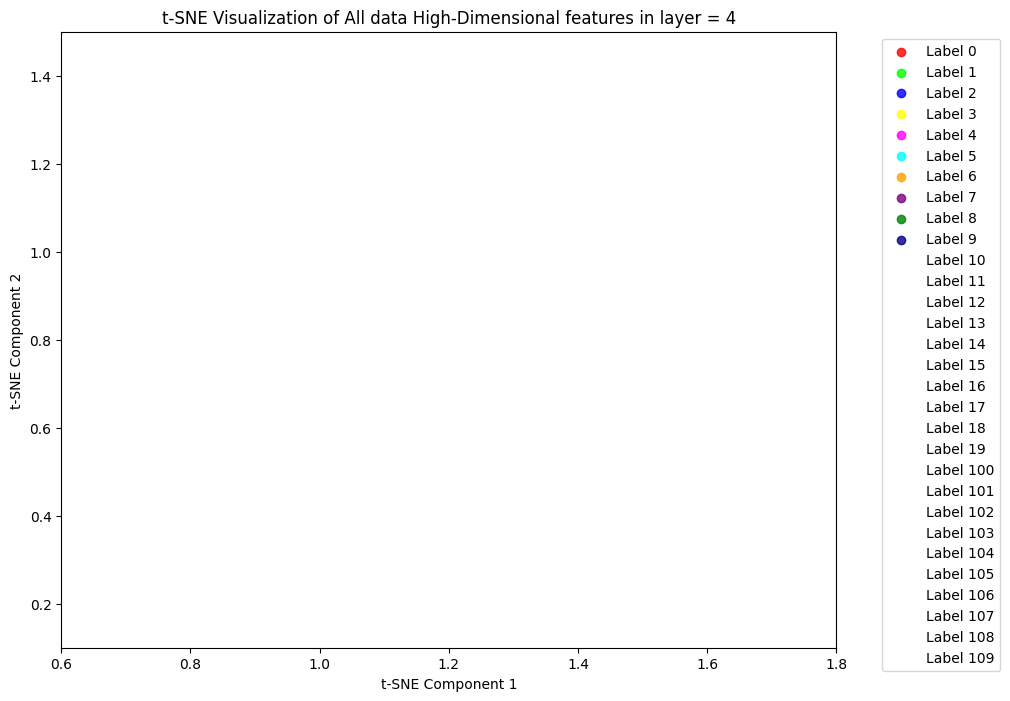

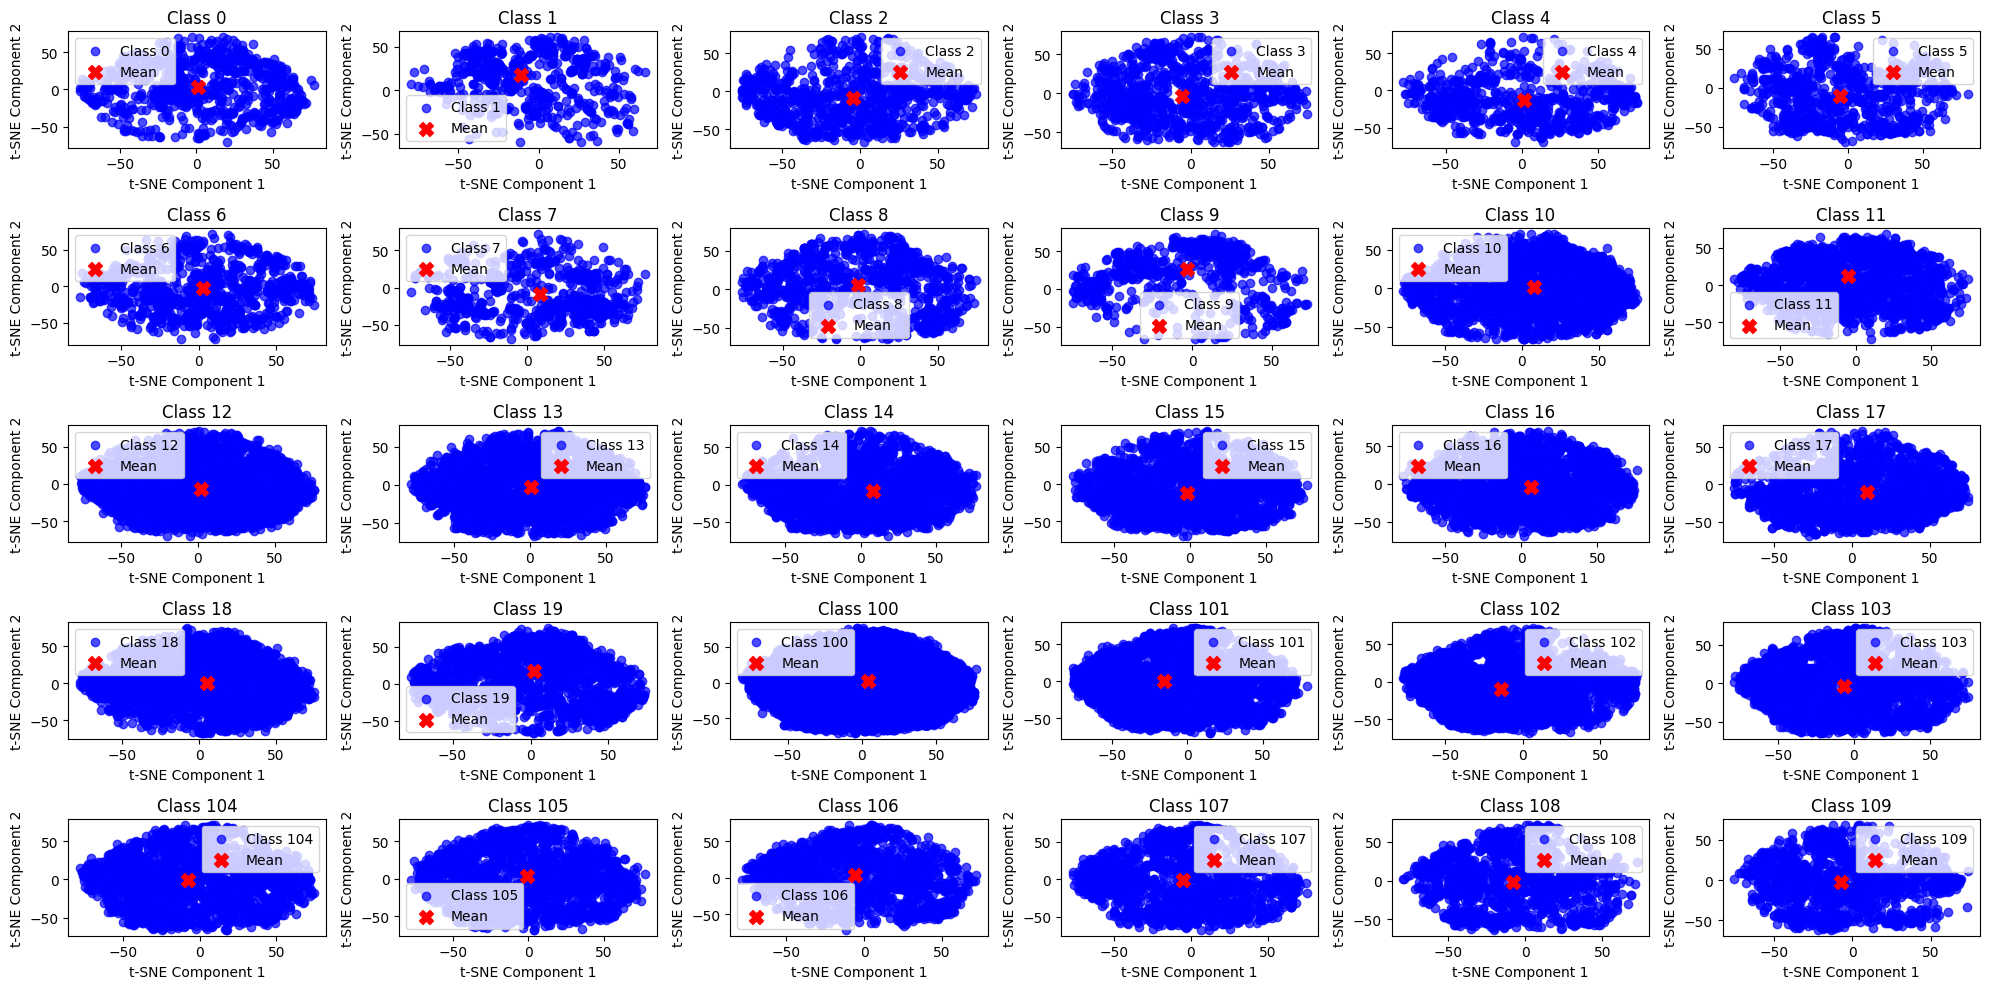

In [ ]:
import cudf
import numpy as np
import torch
from cuml.manifold import TSNE
import matplotlib.pyplot as plt

# Initialize lists
features_all = []
labels_all = []

index = 4
'''
id data label 0 -9
adv attacked data label 10 -19
ood data label 100- 109

'''
# Feature extraction for all the datasets
def featureextract  (testloader,model,device,features_all,labels_all,flag, index):
    j= 0 
    lim = 2500000
    for images, labels in testloader:
        j += 1
        images = images.to(device)
        if flag == 1:
            labels += 100
            # lim = 100
        if flag == 0 :
            labels += 10
            # lim = 100
        features_train = list(model.intermediate_forward(images, layer_index=index))
        for i in range(len(features_train)):
            features_train[i] = features_train[i].view(features_train[i].size(0), features_train[i].size(1), -1)
            features_train[i] = torch.mean(features_train[i].data, 2)  # Global average pooling
        features_all.extend(features_train)  # Append features for the batch
        labels_all.extend(labels.tolist())  # Append labels for the batch
        if j > lim:
            break 



# LoaderList = [pgd_test_loader, test_loader,fgsm_test_loader, Autoattack_test_loader,svhn_test_loader,isun_test_loader,lsun_test_loader]

adv_loaders = [pgd_test_loader, fgsm_test_loader, Autoattack_test_loader]
ood_loaders = [svhn_test_loader, isun_test_loader, lsun_test_loader]


# flag is to denote testset. and change its labels                                          
flag = 0
for loader in adv_loaders:
    featureextract(loader,model,device,features_all,labels_all,0,index)
for loader in ood_loaders:
    featureextract(loader,model,device,features_all,labels_all,1,index)

featureextract(test_loader,model,device,features_all,labels_all,-1,index)

features_tensor = torch.stack(features_all)
features_tensor = features_tensor.reshape(features_tensor.shape[0], -1)

if features_tensor.is_cuda:
    features_array = features_tensor.cpu().numpy()
else:
    features_array = features_tensor.numpy()
gdf = cudf.DataFrame(features_array)
 
tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=5000)
X_embedded = tsne.fit_transform(gdf)
 
print(f"Shape of X_embedded: {X_embedded.shape}")
 
assert len(labels_all) == X_embedded.shape[0], "Mismatch between labels and t-SNE output."
labels_all = np.array(labels_all)
 
X_embedded = X_embedded.to_pandas().to_numpy()
 
df = cudf.DataFrame(X_embedded, columns=['feature1', 'feature2'])
df['labels'] = labels_all

# ## commnt below code 
# z_scores = cudf.DataFrame()

# for col in ['feature1', 'feature2']:
#     mean = df[col].mean()  
#     std = df[col].std()    
#     z_scores[col] = (df[col] - mean) / std 
# threshold = 3

# outlier_rows = (z_scores.abs() > threshold).any(axis=1)

# df = df[~outlier_rows]



# Assuming df is your DataFrame and it has been defined earlier
data = df[['feature1', 'feature2']].to_pandas().values   
labels = df['labels'].to_pandas().values   

plt.figure(figsize=(10, 8))

# Define vibrant colors for labels 0-9
vibrant_colors = [
    '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF', 
    '#FFA500', '#800080', '#008000', '#000080'
]

# Create a colormap for unique colors for each label
color_mapping = {
    '10-19': 'blue',    # Single color for labels 10-19
    '0-9': vibrant_colors,  # List of vibrant colors for labels 0-9
    '100-109': 'red'    # Single color for labels 100-109
}

# Define alpha mapping for each label range
alpha_mapping = {
    '10-19': np.linspace(0.0, 0.0, 10),   
    '0-9': np.linspace(0.8, 0.8, 10),     
    '100-109': np.linspace(0.0,0.0, 10)  
}
 
for label in np.unique(labels):
    mask = labels == label
  
    if 10 <= label <= 19:
        color = color_mapping['10-19']
        alpha = alpha_mapping['10-19'][label - 10]   
    elif 0 <= label <= 9:
        color = color_mapping['0-9'][label]  
        alpha = alpha_mapping['0-9'][label]   
    elif 100 <= label <= 109:
        color = color_mapping['100-109']
        alpha = alpha_mapping['100-109'][label - 100]   
    else:
        continue   
    
    plt.scatter(
        data[mask, 0], 
        data[mask, 1], 
        c=color,  
        alpha=alpha,  
        label=f'Label {label}'
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.title(f't-SNE Visualization of All data High-Dimensional features in layer = {index}')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.xlim(0.6,1.8)
plt.ylim(0.1,1.5)

plt.show()


import matplotlib.pyplot as plt
import numpy as np

# Number of classes to plot
classes =  np.unique(labels)

# Create subplots
fig, axes = plt.subplots(5, 6, figsize=(20, 10))  # Adjust rows and columns as needed
axes = axes.flatten()
p = 0
for target_class in classes:
    
    # Filter the data for the target class
    class_mask = labels_all == target_class
    X_embedded_filtered = X_embedded[class_mask]
    
    # Get the corresponding axis for the subplot
    ax = axes[p]
    p += 1
    mean_embedding = np.mean(X_embedded_filtered, axis=0)
    # Plot the t-SNE visualization for the specific class
    ax.scatter(X_embedded_filtered[:, 0], X_embedded_filtered[:, 1], 
               c='blue', alpha=0.7, label=f'Class {target_class}')
    ax.scatter(mean_embedding[0], mean_embedding[1], 
               c='red', marker='X', s=100, label='Mean')
    ax.set_title(f'Class {target_class}')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

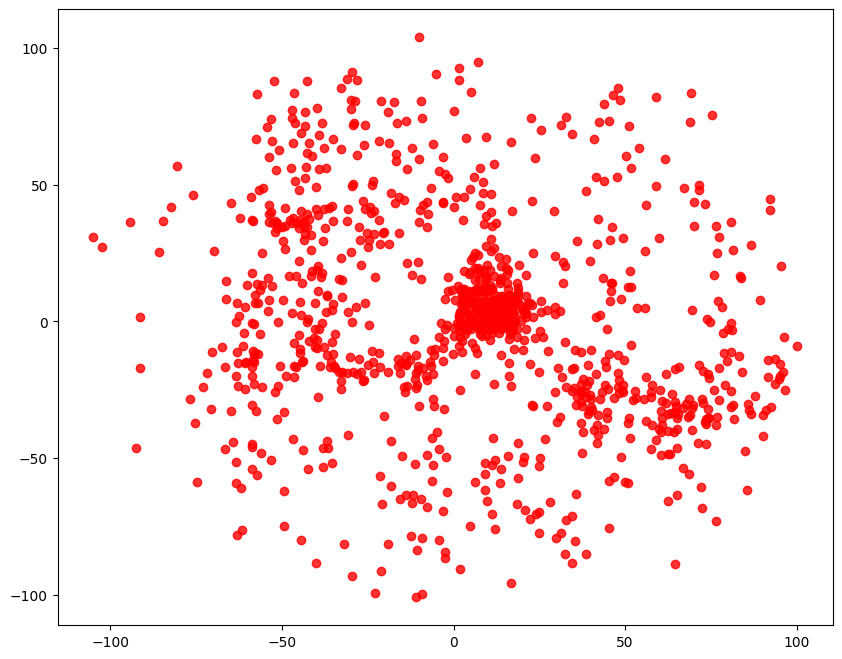

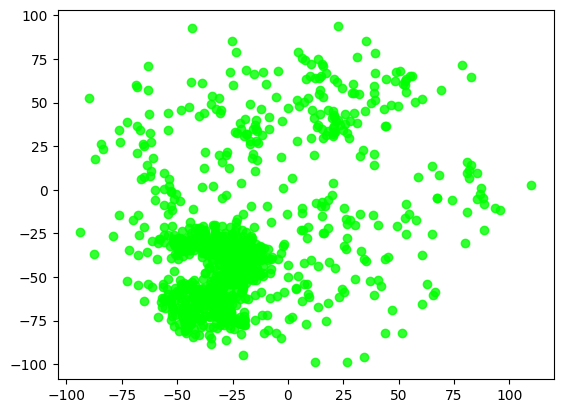

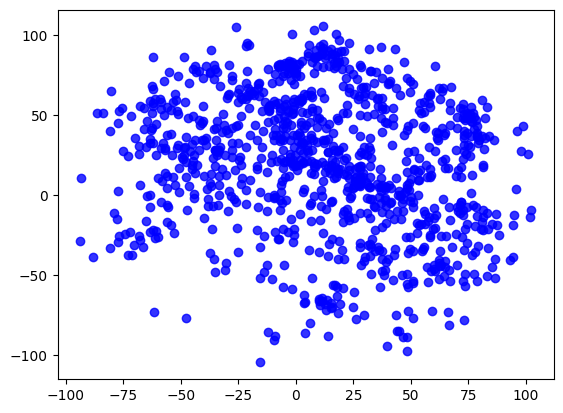

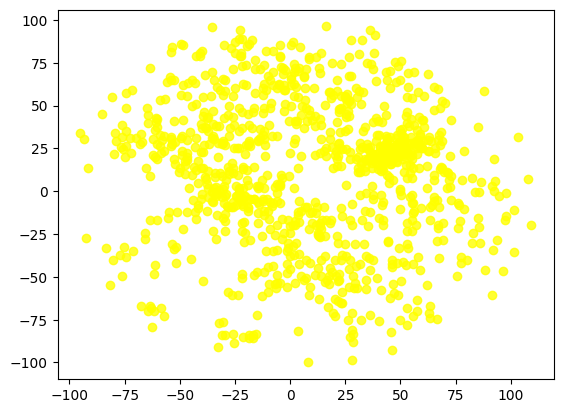

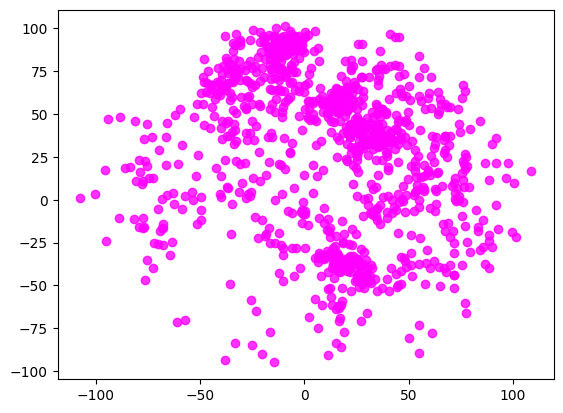

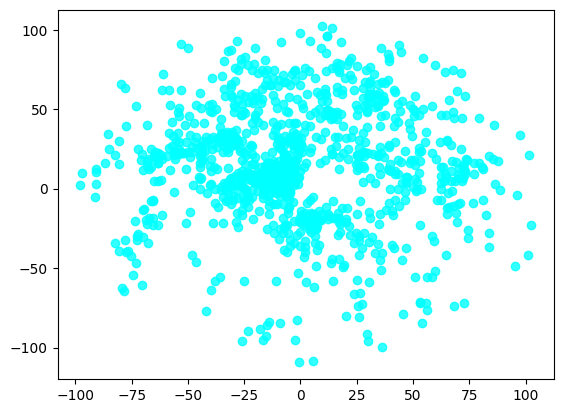

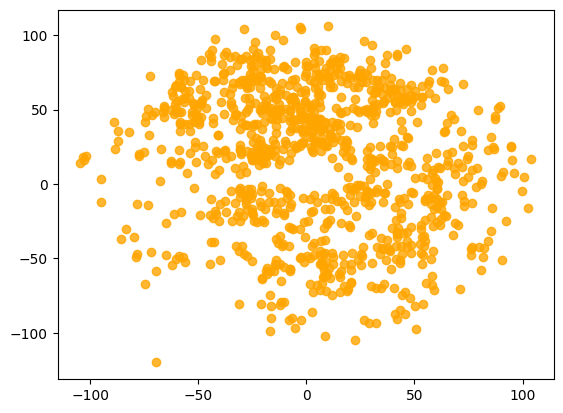

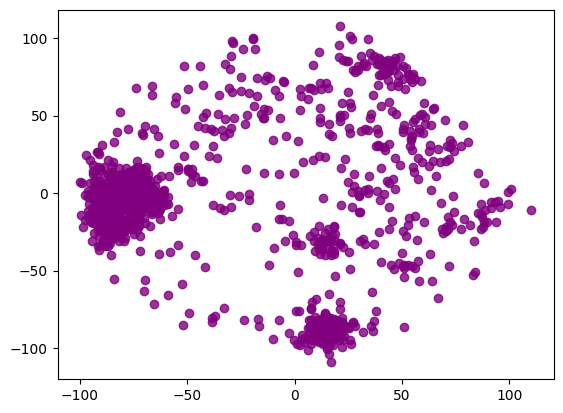

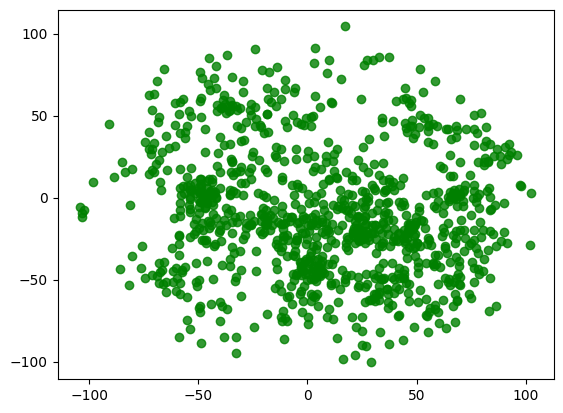

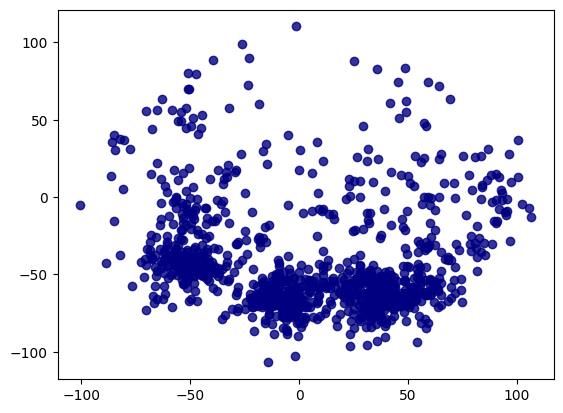

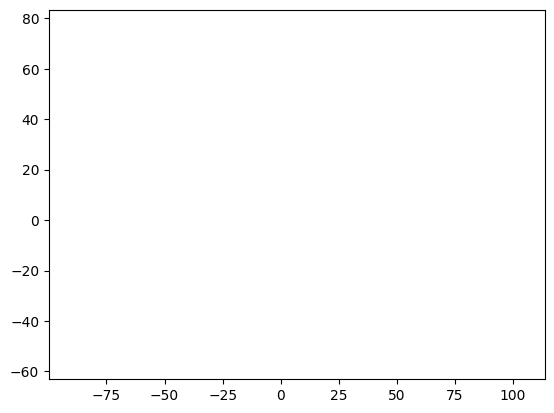

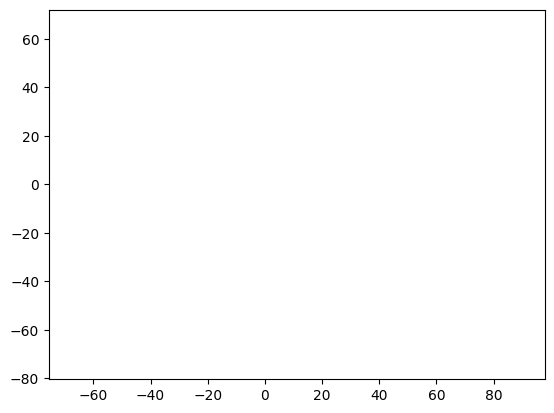

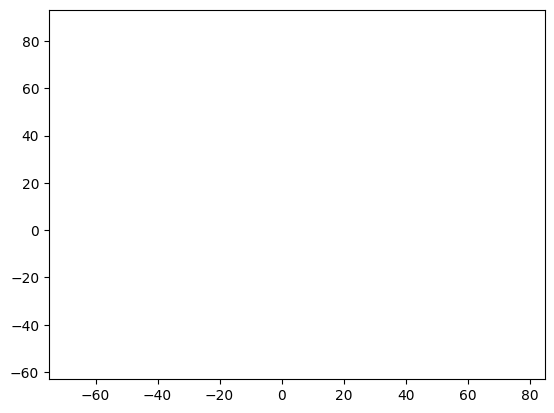

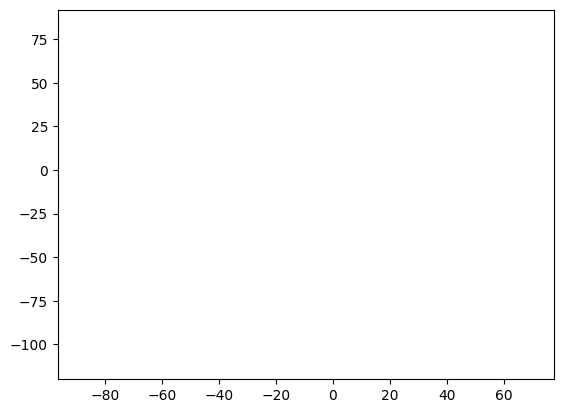

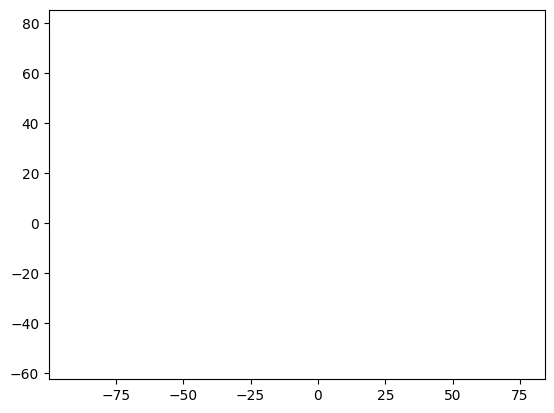

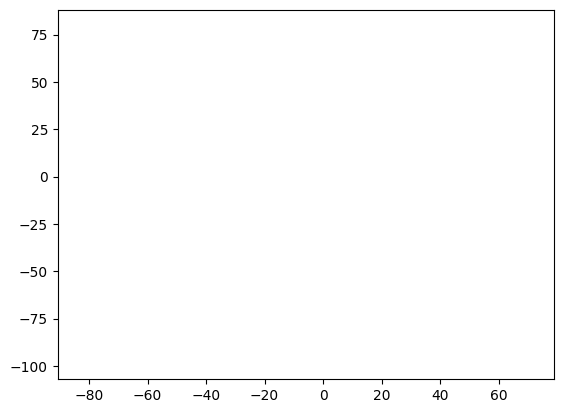

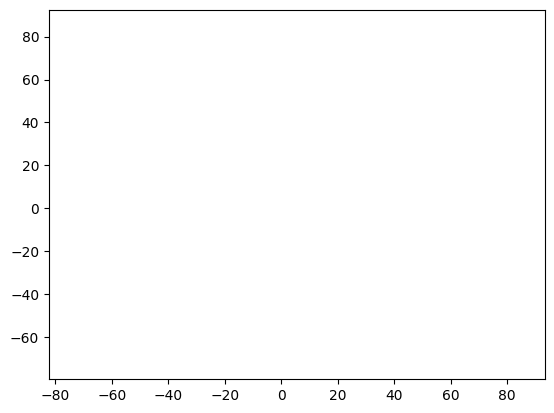

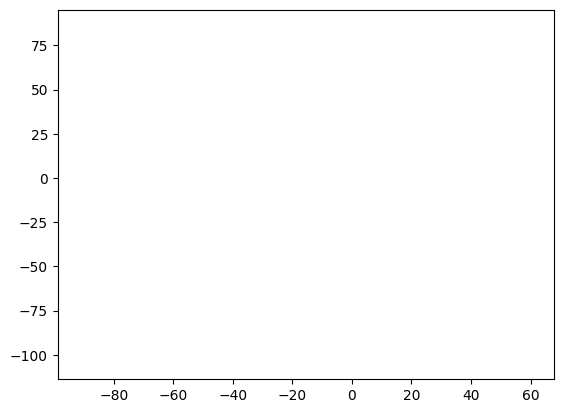

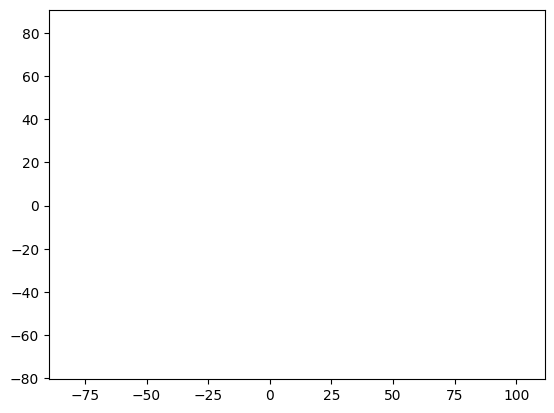

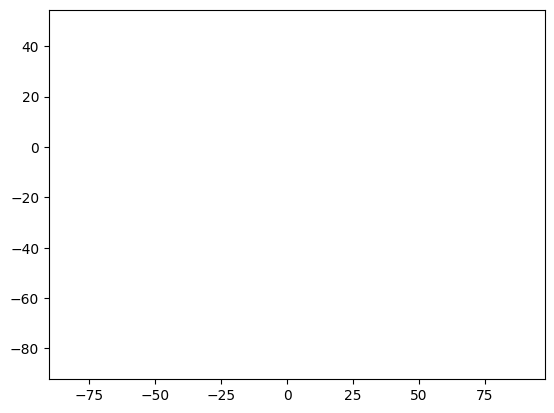

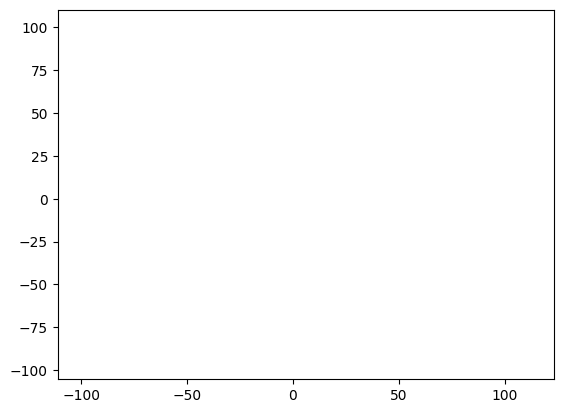

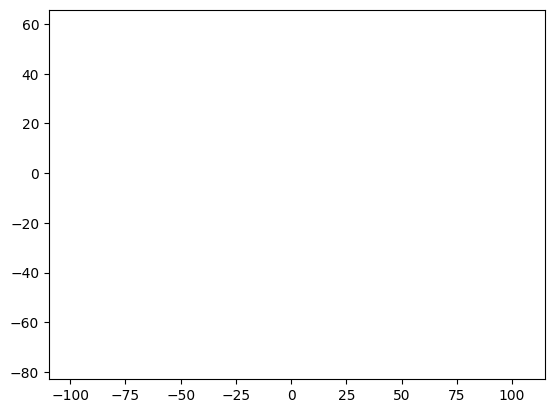

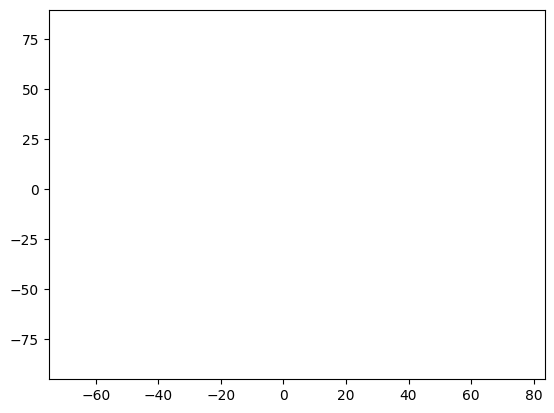

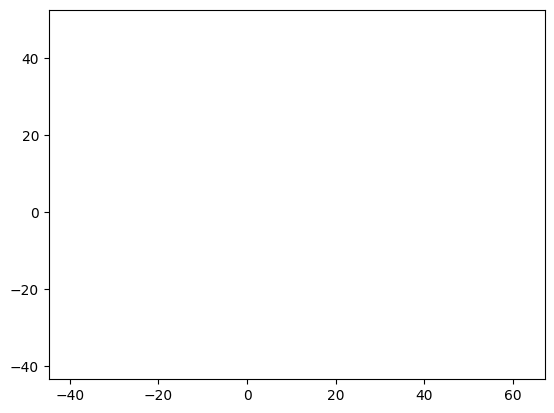

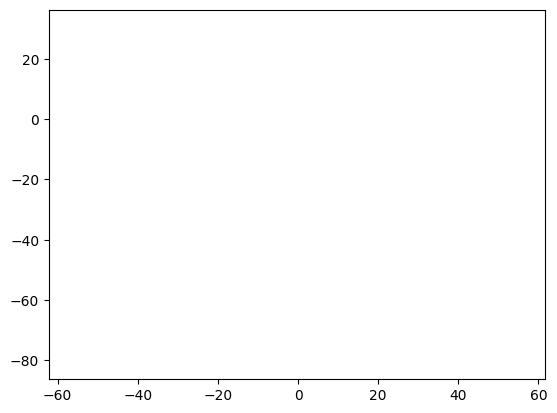

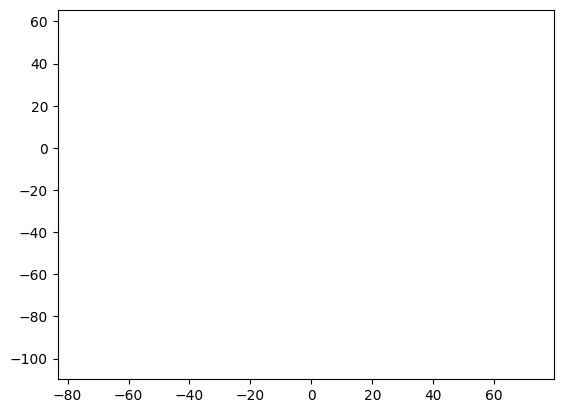

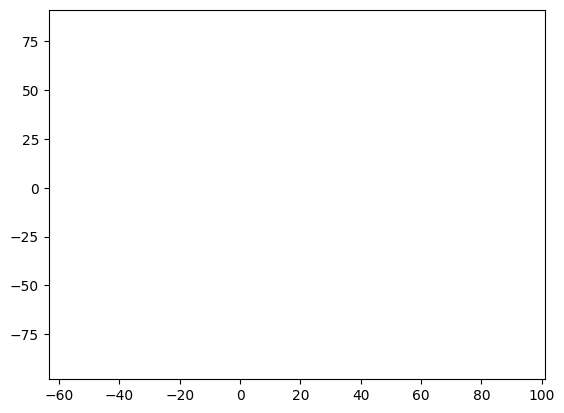

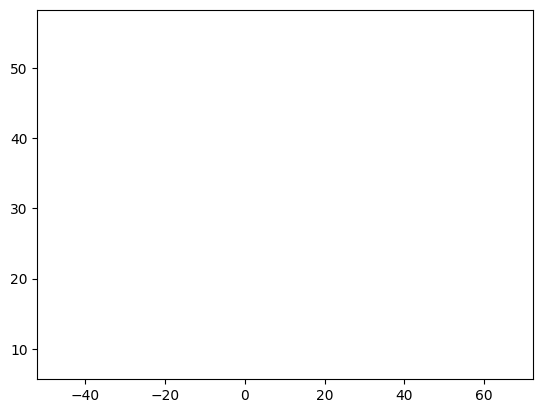

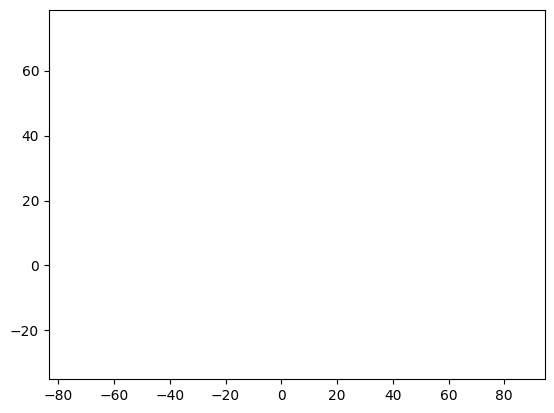

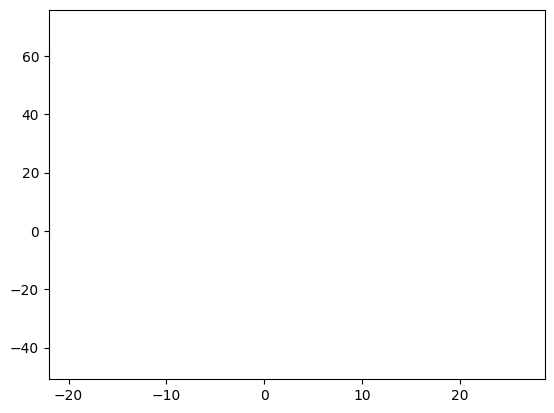

/tmp/ipykernel_2456043/3925365513.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


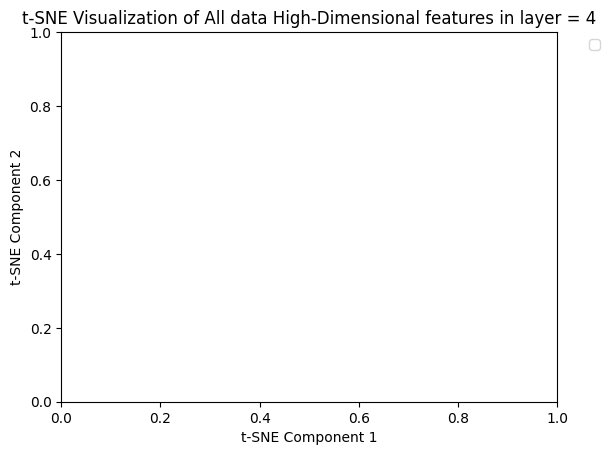

In [9]:
# Assuming df is your DataFrame and it has been defined earlier
data = df[['feature1', 'feature2']].to_pandas().values   
labels = df['labels'].to_pandas().values   

plt.figure(figsize=(10, 8))

# Define vibrant colors for labels 0-9
vibrant_colors = [
    '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF', 
    '#FFA500', '#800080', '#008000', '#000080'
]

# Create a colormap for unique colors for each label
color_mapping = {
    '10-19': 'blue',    # Single color for labels 10-19
    '0-9': vibrant_colors,  # List of vibrant colors for labels 0-9
    '100-109': 'red'    # Single color for labels 100-109
}

# Define alpha mapping for each label range
alpha_mapping = {
    '10-19': np.linspace(0.0, 0.0, 10),  # 10 alpha values for labels 10-19
    '0-9': np.linspace(0.8, 0.8, 10),    # 10 alpha values for labels 0-9
    '100-109': np.linspace(0.0,0.0, 10) # 10 alpha values for labels 100-109
}

# Plot each label with its specific color and alpha value
for label in np.unique(labels):
    mask = labels == label
    
    # Determine which range the label belongs to
    if 10 <= label <= 19:
        color = color_mapping['10-19']
        alpha = alpha_mapping['10-19'][label - 10]  # Get alpha value for this label
    elif 0 <= label <= 9:
        color = color_mapping['0-9'][label]  # Get vibrant color for this label
        alpha = alpha_mapping['0-9'][label]  # Get alpha value for this label
    elif 100 <= label <= 109:
        color = color_mapping['100-109']
        alpha = alpha_mapping['100-109'][label - 100]  # Get alpha value for this label
    else:
        continue  # Skip labels outside the specified ranges
    
    plt.scatter(
        data[mask, 0], 
        data[mask, 1], 
        c=color,  
        alpha=alpha,  # Specific alpha for the label
        label=f'Label {label}'
    )
    plt.show()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.title(f't-SNE Visualization of All data High-Dimensional features in layer = {index}')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
# plt.xlim(1.15e-5,1.25e-5)
# plt.ylim(0.7e-5,0.9e-5)

plt.show()

In [35]:
uniq_classes = []
for image,labels in lsun_test_loader:
    for label in labels:
        if label not in uniq_classes:
            uniq_classes += [label]
print(uniq_classes)

[tensor(0)]


[W] [12:52:05.721787] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


/tmp/ipykernel_2586779/889892244.py:53: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 12
  plt.legend(handles=scatter.legend_elements()[0], labels=["Class 0", "Class 1","Class 0 pgd", "Class 1 pgd","Class 0 fgsm", "Class 1 fgsm", "Class 0 aa", "Class 1 aa","Class 0 SVHN", "Class 1 SVHN", "Class 0 LSUN", "Class 1 LSUN"], title="Classes")


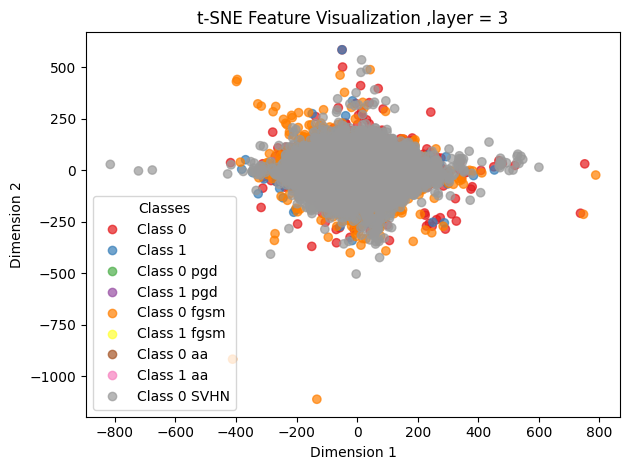

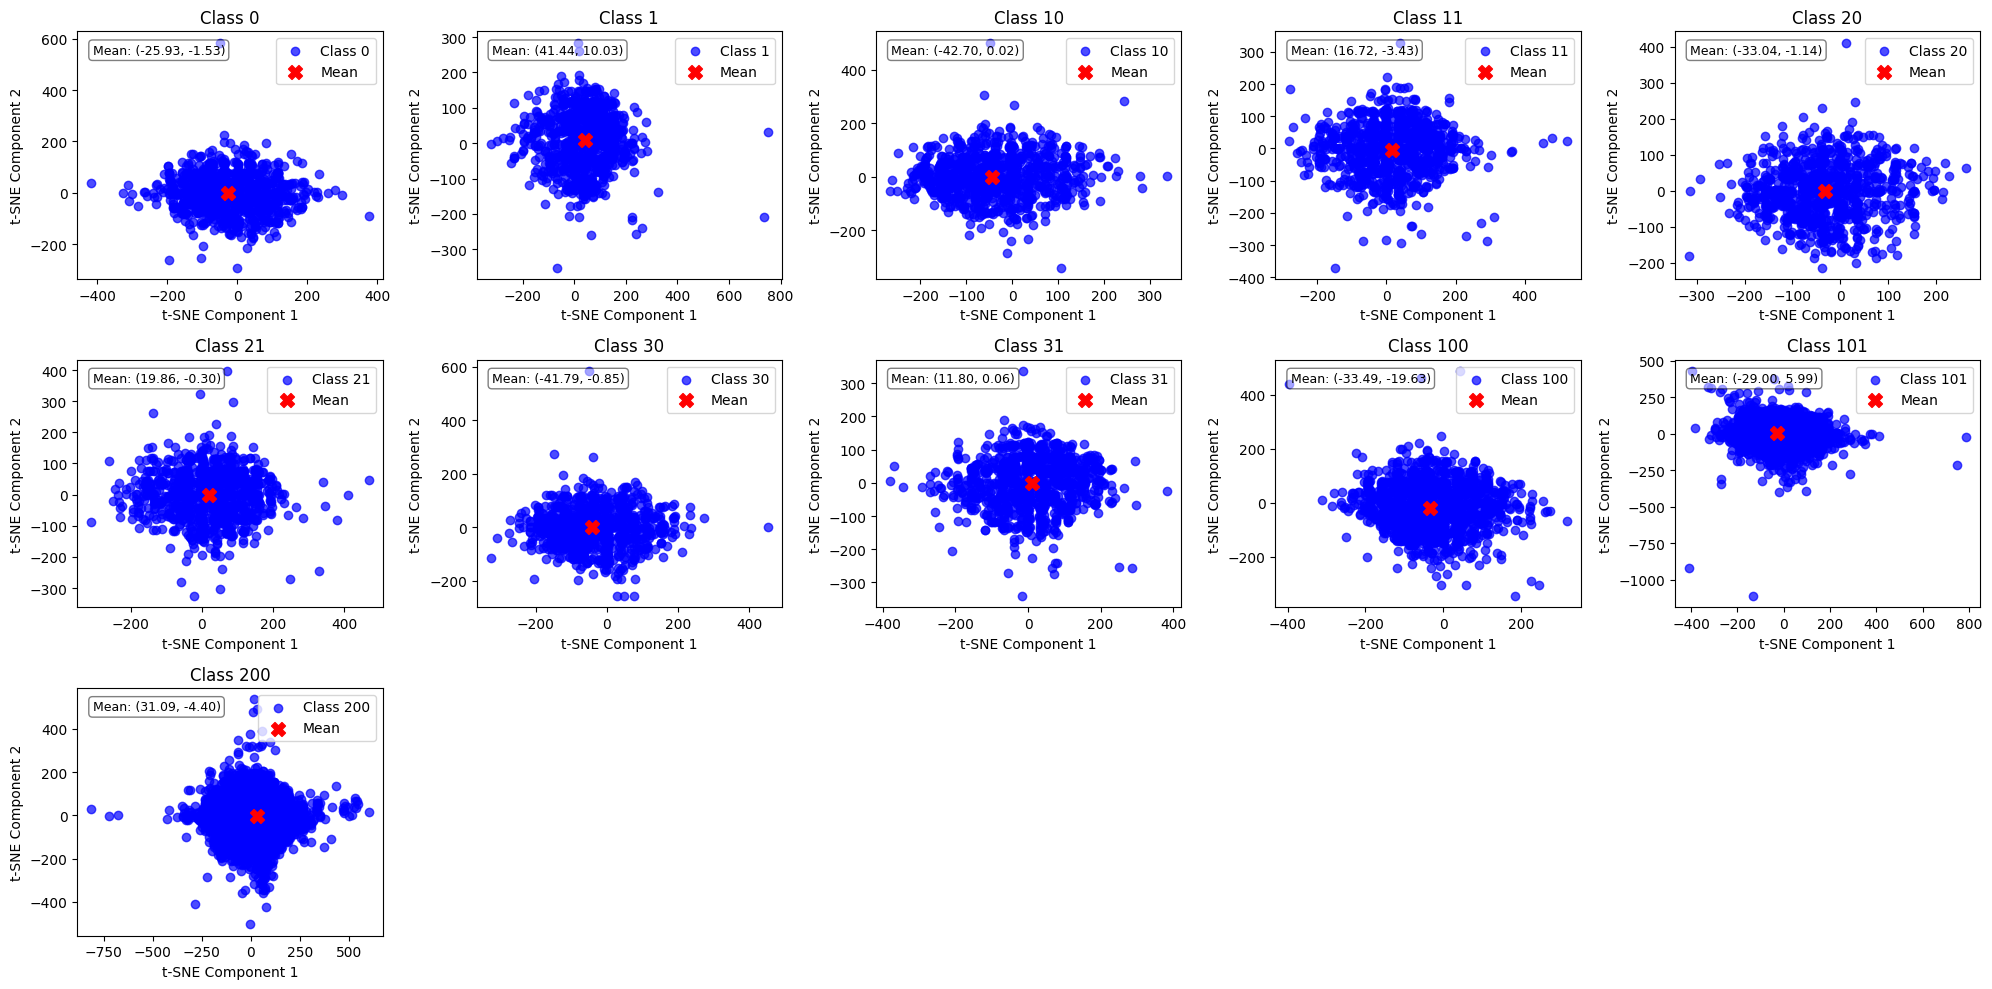

In [42]:
import torch
import matplotlib.pyplot as plt
from cuml.decomposition import PCA
from cuml.manifold import TSNE

features_0 = []
labels = []
layer_index = 3
model.eval()
loaders = [test_loader, pgd_test_loader,fgsm_test_loader, Autoattack_test_loader,svhn_test_loader,lsun_test_loader]
with torch.no_grad():
    for loader in loaders:
        for inputs, targets in loader:
            inputs = inputs.cuda() 
             
            class_mask = (targets == 0) | (targets == 1)
            inputs = inputs[class_mask]
            targets = targets[class_mask]
            
            if len(targets) == 0:
                continue   
            if loader == pgd_test_loader:
                targets += 10
            if loader == fgsm_test_loader:
                targets += 20
            if loader == Autoattack_test_loader:
                targets += 30
            if loader == svhn_test_loader:
                targets += 100
            if loader == lsun_test_loader:
                targets += 200

            layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
            layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
            features_0.append(layer1_features_flat.cpu())
            labels.append(targets.cpu())

features_0 = torch.cat(features_0, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()



tsne = TSNE(n_components=2, perplexity=50, random_state=0)
tsne_features = tsne.fit_transform(features_0)




scatter = plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='Set1', alpha=0.7)
plt.title(f"t-SNE Feature Visualization ,layer = {layer_index}")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(handles=scatter.legend_elements()[0], labels=["Class 0", "Class 1","Class 0 pgd", "Class 1 pgd","Class 0 fgsm", "Class 1 fgsm", "Class 0 aa", "Class 1 aa","Class 0 SVHN", "Class 1 SVHN", "Class 0 LSUN", "Class 1 LSUN"], title="Classes")
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(3, 5, figsize=(20, 10))   
axes = axes.ravel()
unique_classes = np.unique(labels)
for i, target_class in enumerate(unique_classes):

    class_mask = labels == target_class
    X_embedded_filtered = tsne_features[class_mask]
    mean_embedding = np.mean(X_embedded_filtered, axis=0)
    ax = axes[i]
    ax.scatter(X_embedded_filtered[:, 0], X_embedded_filtered[:, 1], 
               c='blue', alpha=0.7, label=f'Class {target_class}')
    ax.scatter(mean_embedding[0], mean_embedding[1], 
               c='red', marker='X', s=100, label='Mean')
    mean_coords_text = f'Mean: ({mean_embedding[0]:.2f}, {mean_embedding[1]:.2f})'
    ax.text(0.05, 0.95, mean_coords_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
    ax.set_title(f'Class {target_class}')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.legend()

for j in range(len(unique_classes), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## get the distance of points from a point of reference (0,0,0)

In [50]:
def sum_of_squares(arr):
    return sum(x**2 for x in arr)

In [11]:
import torch
import matplotlib.pyplot as plt
from cuml.decomposition import PCA
from cuml.manifold import TSNE
import cupy as cp 
import csv

distance_0 = []
distance_1 = []
distance_2 = []
distance_3 = []
distance_4 = []
labels = []


layer_index = -1
model.eval()
loaders = [test_loader, pgd_test_loader,fgsm_test_loader, Autoattack_test_loader,svhn_test_loader,lsun_test_loader,isun_test_loader,dtd_test_loader,cifar100_test_loader]
with torch.no_grad():
    for loader in loaders:
        for inputs, targets in loader:
            inputs = inputs.cuda() 
             
            # class_mask = (targets == 0) | (targets == 1)
            # inputs = inputs[class_mask]
            # targets = targets[class_mask]
            
            if len(targets) == 0:
                continue   
            if loader == pgd_test_loader:
                targets += 10
            if loader == fgsm_test_loader:
                targets += 20
            if loader == Autoattack_test_loader:
                targets += 30
            if loader == svhn_test_loader:
                targets += 100
            if loader == lsun_test_loader:
                targets += 200
            if loader == isun_test_loader:
                targets += 300
            if loader == dtd_test_loader:
                targets += 400
            if loader == cifar100_test_loader:
                targets += 500

            f0,f1,f2,f3,f4= model.intermediate_forward(inputs, layer_index=-1)
            f0 = f0.view(f0.size(0), -1)
            f1 = f1.view(f0.size(0), -1)
            f2 = f2.view(f0.size(0), -1)
            f3 = f3.view(f0.size(0), -1)
            f4 = f4.view(f0.size(0), -1)
            f0 = cp.asarray(f0)
            f1 = cp.asarray(f1)
            f2 = cp.asarray(f2)
            f3 = cp.asarray(f3)
            f4 = cp.asarray(f4)
            
            
            # distance_0 += cp.array([cp.sum(cp.square(cp.array(sublist))) for sublist in f0])
            # distance_1 += cp.array([cp.sum(cp.square(cp.array(sublist))) for sublist in f1])
            # distance_2 += cp.array([cp.sum(cp.square(cp.array(sublist))) for sublist in f2])
            # distance_3 += cp.array([cp.sum(cp.square(cp.array(sublist))) for sublist in f3])
            # distance_4 += cp.array([cp.sum(cp.square(cp.array(sublist))) for sublist in f4])
            # Assuming f0, f1, f2, f3, f4 are already 2D CuPy arrays
            distance_0 += list(cp.sum(cp.square(f0), axis=1))
            distance_1 += list(cp.sum(cp.square(f1), axis=1))
            distance_2 += list(cp.sum(cp.square(f2), axis=1))
            distance_3 += list(cp.sum(cp.square(f3), axis=1))
            distance_4 += list(cp.sum(cp.square(f4), axis=1))
            labels.append(targets.cpu())
            

with open('./results/distance.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["DataType","True label", "Layer0", "Layer1" , "Layer2", "Layer3", "Layer4"])
    for i in range(len(distance_0)):
        dtype = "Random"
        if labels[i] < 10 :
            dtype = "ID"
        elif labels[i] < 20:
            labels[i] -= 10
            dtype = "PGD"
        elif labels[i] <30:
            labels[i] -= 20
            dtype = "FGSM"
        elif labels[i] <100 :
            labels[i] -= 30
            dtype = "AA"
        elif labels[i] <200 :
            labels[i] -= 100
            dtype = "SVHN"
        elif labels[i] <300:
            labels[i] -= 200
            dtype = "LSUN"
        elif labels[i] <400:
            labels[i] -= 300
            dtype = "iSUN"
        elif labels[i] <500:
            labels[i] -= 400
            dtype = "dtd"
        elif labels[i] <600:
            labels[i] -= 500
            dtype = "cifar100"

        writer.writerow([dtype,labels[i],distance_0[i], distance_1[i], distance_2[i], distance_3[i], distance_4[i]])



KeyboardInterrupt: 

## Analysis  of the CSV

In [24]:
import pandas as pd
import numpy as np
from scipy.stats import scoreatpercentile


df = pd.read_csv('./results/distance.csv')
id_data = df[df['DataType'] == 'ID']
thresholds = {}


for layer in ['Layer0', 'Layer1', 'Layer2', 'Layer3', 'Layer4']:
    thresholds[layer] = np.percentile(id_data[layer], 5)
 
below_threshold_percentages = {}

for data_type in df['DataType'].unique():
    if data_type == 'ID':
        continue
    
     
    data_type_df = df[df['DataType'] == data_type]
    
     
    below_threshold_percentages[data_type] = {}
    
     
    for layer in ['Layer0', 'Layer1', 'Layer2', 'Layer3', 'Layer4']:
        below_threshold_percentages[data_type][layer] = (
            (data_type_df[layer] < thresholds[layer]).mean() * 100
        )

# Print the thresholds
print("95% TPR Thresholds for ID DataType:")
print(thresholds)

# Print the percentages of values below the threshold for other DataTypes
print("\nPercentage of Values Below Threshold for Other DataTypes:")
for data_type, percentages in below_threshold_percentages.items():
    print(f"\nData Type: {data_type}")
    for layer, percentage in percentages.items():
        print(f"{layer}: {percentage:.2f}%")

95% TPR Thresholds for ID DataType:
{'Layer0': np.float64(979.382828), 'Layer1': np.float64(1226.864545), 'Layer2': np.float64(651.283465), 'Layer3': np.float64(77.84940870000001), 'Layer4': np.float64(804.277422)}

Percentage of Values Below Threshold for Other DataTypes:

Data Type: PGD
Layer0: 3.83%
Layer1: 0.59%
Layer2: 0.15%
Layer3: 3.76%
Layer4: 3.55%

Data Type: FGSM
Layer0: 2.47%
Layer1: 0.00%
Layer2: 0.01%
Layer3: 8.01%
Layer4: 6.34%

Data Type: AA
Layer0: 3.84%
Layer1: 0.66%
Layer2: 0.34%
Layer3: 4.23%
Layer4: 4.86%

Data Type: SVHN
Layer0: 34.83%
Layer1: 13.72%
Layer2: 86.56%
Layer3: 91.55%
Layer4: 66.22%

Data Type: LSUN
Layer0: 0.10%
Layer1: 0.06%
Layer2: 1.02%
Layer3: 29.30%
Layer4: 60.05%

Data Type: iSUN
Layer0: 0.48%
Layer1: 0.24%
Layer2: 2.31%
Layer3: 33.94%
Layer4: 58.68%

Data Type: dtd
Layer0: 19.79%
Layer1: 27.18%
Layer2: 33.83%
Layer3: 62.77%
Layer4: 41.44%

Data Type: cifar100
Layer0: 4.47%
Layer1: 5.07%
Layer2: 8.92%
Layer3: 29.32%
Layer4: 32.45%


In [15]:
# Initialize a dictionary to store the accuracy for each layer
id_accuracy = {}

# Calculate the accuracy for each layer
for layer in ['Layer0', 'Layer1', 'Layer2', 'Layer3', 'Layer4']:
    # Count the number of values below the 95% TPR threshold
    below_threshold_count = (id_data[layer] > thresholds[layer]).sum()
    
    # Calculate the accuracy as a percentage
    id_accuracy[layer] = (below_threshold_count / len(id_data)) * 100
# Print the accuracy for the ID dataset
print("Accuracy for ID Dataset (Percentage of Values Below 95% TPR Threshold):")
for layer, accuracy in id_accuracy.items():
    print(f"{layer}: {accuracy:.2f}%")

Accuracy for ID Dataset (Percentage of Values Below 95% TPR Threshold):
Layer0: 95.00%
Layer1: 95.00%
Layer2: 95.00%
Layer3: 95.00%
Layer4: 95.00%


In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

# Load the data
df = pd.read_csv('./results/distance.csv')

# Filter the ID data
id_data = df[df['DataType'] == 'ID']

# Initialize a dictionary to store AUROC values
auroc_scores = {}

# Calculate the AUROC for each data type other than ID
for data_type in df['DataType'].unique():
    if data_type == 'ID':
        continue
    
    # Filter the data for the current data type
    data_type_df = df[df['DataType'] == data_type]
    
    # Combine the ID data and the current data type data
    combined_data = pd.concat([id_data, data_type_df])
    
    # Create binary labels: 1 for ID, 0 for the current data type
    labels = np.where(combined_data['DataType'] == 'ID', 1, 0)
    
    # Initialize a dictionary to store AUROC scores for each layer
    auroc_scores[data_type] = {}
    
    # Calculate AUROC for each layer
    for layer in ['Layer0', 'Layer1', 'Layer2', 'Layer3', 'Layer4']:
        # Get the scores (mean distances) for the current layer
        scores = combined_data[layer]
        
        # Calculate the AUROC
        auroc_scores[data_type][layer] = roc_auc_score(labels, scores)

# Print the AUROC scores
print("AUROC Scores for DataTypes Other Than ID:")
for data_type, scores in auroc_scores.items():
    print(f"\nData Type: {data_type}")
    for layer, auroc in scores.items():
        print(f"{layer}: {auroc:.4f}")

AUROC Scores for DataTypes Other Than ID:

Data Type: PGD
Layer0: 0.4874
Layer1: 0.3604
Layer2: 0.3823
Layer3: 0.6103
Layer4: 0.3400

Data Type: FGSM
Layer0: 0.4561
Layer1: 0.0817
Layer2: 0.2948
Layer3: 0.6869
Layer4: 0.4104

Data Type: AA
Layer0: 0.4882
Layer1: 0.3510
Layer2: 0.3817
Layer3: 0.6214
Layer4: 0.3657

Data Type: SVHN
Layer0: 0.7878
Layer1: 0.7984
Layer2: 0.9689
Layer3: 0.9828
Layer4: 0.8914

Data Type: LSUN
Layer0: 0.1822
Layer1: 0.0441
Layer2: 0.3212
Layer3: 0.8926
Layer4: 0.9054

Data Type: iSUN
Layer0: 0.2238
Layer1: 0.0737
Layer2: 0.3663
Layer3: 0.8969
Layer4: 0.8950

Data Type: dtd
Layer0: 0.5507
Layer1: 0.5619
Layer2: 0.6850
Layer3: 0.9004
Layer4: 0.7727

Data Type: cifar100
Layer0: 0.4332
Layer1: 0.4563
Layer2: 0.5368
Layer3: 0.8339
Layer4: 0.7600


## find  Centriod !

In [5]:
import torch
import matplotlib.pyplot as plt
# from cuml.decomposition import PCA
# from cuml.manifold import TSNE
import cupy as cp 
# import csv

# Initialize variables to store the rolling sum and count
flag = 0
batch_count = 0

 
labels = []

layer_index = -1
model.eval()
loaders = train_loader
with torch.no_grad():
    # for loader in loaders:
    for inputs, targets in loaders:
        inputs = inputs.to(device)

        f0, f1, f2, f3, f4 = model.intermediate_forward(inputs, layer_index=-1)
        f0 = f0.view(f0.size(0), -1)
        f1 = f1.view(f1.size(0), -1)
        f2 = f2.view(f2.size(0), -1)
        f3 = f3.view(f3.size(0), -1)
        f4 = f4.view(f4.size(0), -1)

        f0 = cp.asarray(f0)
        f1 = cp.asarray(f1)
        f2 = cp.asarray(f2)
        f3 = cp.asarray(f3)
        f4 = cp.asarray(f4)
        if flag == 0:
            rolling_sum_f0 = cp.zeros((1, f0.shape[1]))  # Assuming f0 is a 2D array
            rolling_sum_f1 = cp.zeros((1, f1.shape[1]))
            rolling_sum_f2 = cp.zeros((1, f2.shape[1]))
            rolling_sum_f3 = cp.zeros((1, f3.shape[1]))
            rolling_sum_f4 = cp.zeros((1, f4.shape[1]))
            flag += 1
                    
        rolling_sum_f0 += cp.sum(f0, axis=0)
        rolling_sum_f1 += cp.sum(f1, axis=0)
        rolling_sum_f2 += cp.sum(f2, axis=0)
        rolling_sum_f3 += cp.sum(f3, axis=0)
        rolling_sum_f4 += cp.sum(f4, axis=0)

        batch_count += f0.shape[0]

        rolling_mean_f0 = rolling_sum_f0 / batch_count
        rolling_mean_f1 = rolling_sum_f1 / batch_count
        rolling_mean_f2 = rolling_sum_f2 / batch_count
        rolling_mean_f3 = rolling_sum_f3 / batch_count
        rolling_mean_f4 = rolling_sum_f4 / batch_count


        labels.extend(targets.cpu().numpy())


print("Rolling Mean f0:", rolling_mean_f0)
print("Rolling Mean f1:", rolling_mean_f1)
print("Rolling Mean f2:", rolling_mean_f2)
print("Rolling Mean f3:", rolling_mean_f3)
print("Rolling Mean f4:", rolling_mean_f4)

Rolling Mean f0: [[0. 0. 0. ... 0. 0. 0.]]
Rolling Mean f1: [[0.24220111 0.20578043 0.21113999 ... 0.09617823 0.12986325 0.10332896]]
Rolling Mean f2: [[0.07517604 0.03376964 0.0354746  ... 0.0458325  0.05700758 0.06255987]]
Rolling Mean f3: [[0.00121009 0.00343213 0.00398058 ... 0.00570708 0.00662431 0.01000533]]
Rolling Mean f4: [[0.13970698 0.14897522 0.15048141 ... 0.12362731 0.12769712 0.11704842]]


In [3]:
rolling_mean_f0.shape

(1, 65536)

## use centroid 

In [16]:

import torch
# import matplotlib.pyplot as plt
# from cuml.decomposition import PCA
# from cuml.manifold import TSNE
import cupy as cp 
import csv

distance_0 = []
distance_1 = []
distance_2 = []
distance_3 = []
distance_4 = []
labels = []


layer_index = -1
model.eval()
loaders = [test_loader, pgd_test_loader,fgsm_test_loader, Autoattack_test_loader,svhn_test_loader,lsun_test_loader,isun_test_loader,dtd_test_loader,cifar100_test_loader]
with torch.no_grad():
    for loader in loaders:
        for inputs, targets in loader:
            inputs = inputs.to(device)
             
            # class_mask = (targets == 0) | (targets == 1)
            # inputs = inputs[class_mask]
            # targets = targets[class_mask]
            
            if len(targets) == 0:
                continue   
            elif loader == pgd_test_loader:
                targets += 10
            elif loader == fgsm_test_loader:
                targets += 20
            elif loader == Autoattack_test_loader:
                targets += 30
            elif loader == svhn_test_loader:
                targets += 100
            elif loader == lsun_test_loader:
                targets += 200
            elif loader == isun_test_loader:
                targets += 300
            elif loader == dtd_test_loader:
                targets += 400
            elif loader == cifar100_test_loader:
                targets += 500

            f0,f1,f2,f3,f4= model.intermediate_forward(inputs, layer_index=-1)
            f0 = f0.view(f0.size(0), -1)
            f1 = f1.view(f0.size(0), -1)
            f2 = f2.view(f0.size(0), -1)
            f3 = f3.view(f0.size(0), -1)
            f4 = f4.view(f0.size(0), -1)
            f0 = cp.asarray(f0)
            f1 = cp.asarray(f1)
            f2 = cp.asarray(f2)
            f3 = cp.asarray(f3)
            f4 = cp.asarray(f4)
            # print(len(f0))
            distance_0 += [cp.linalg.norm(x - rolling_mean_f0) for x in f0]
            # print(len(distance_0))
            distance_1 += [cp.linalg.norm(x - rolling_mean_f1) for x in f1]
            distance_2 += [cp.linalg.norm(x - rolling_mean_f2) for x in f2]
            distance_3 += [cp.linalg.norm(x - rolling_mean_f3) for x in f3]
            distance_4 += [cp.linalg.norm(x - rolling_mean_f4) for x in f4]
            labels+= targets.cpu().tolist()
            # break
            # print(distance_0)
            # break





In [17]:
len(labels)

96837

In [18]:

with open('./results/Mean_distance.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["DataType","True label", "Layer0", "Layer1" , "Layer2", "Layer3", "Layer4"])
    for i in range(len(distance_0)):
        dtype = "Random"
        if labels[i] < 10 :
            dtype = "ID"
        elif labels[i] < 20:
            labels[i] -= 10
            dtype = "PGD"
        elif labels[i] <30:
            labels[i] -= 20
            dtype = "FGSM"
        elif labels[i] <100 :
            labels[i] -= 30
            dtype = "AA"
        elif labels[i] <200 :
            labels[i] -= 100
            dtype = "SVHN"
        elif labels[i] <300:
            labels[i] -= 200
            dtype = "LSUN"
        elif labels[i] <400:
            labels[i] -= 300
            dtype = "iSUN"
        elif labels[i] <500:
            labels[i] -= 400
            dtype = "dtd"
        elif labels[i] <600:
            labels[i] -= 500
            dtype = "cifar100"

        writer.writerow([dtype,labels[i],distance_0[i], distance_1[i], distance_2[i], distance_3[i], distance_4[i]])


In [19]:
import pandas as pd
import numpy as np
from scipy.stats import scoreatpercentile


df = pd.read_csv('./results/Mean_distance.csv')
id_data = df[df['DataType'] == 'ID']
thresholds = {}


for layer in ['Layer0', 'Layer1', 'Layer2', 'Layer3', 'Layer4']:
    thresholds[layer] = np.percentile(id_data[layer], 5)
 
below_threshold_percentages = {}

for data_type in df['DataType'].unique():
    if data_type == 'ID':
        continue
    
     
    data_type_df = df[df['DataType'] == data_type]
    
     
    below_threshold_percentages[data_type] = {}
    
     
    for layer in ['Layer0', 'Layer1', 'Layer2', 'Layer3', 'Layer4']:
        below_threshold_percentages[data_type][layer] = (
            (data_type_df[layer] < thresholds[layer]).mean() * 100
        )

# Print the thresholds
print("95% TPR Thresholds for ID DataType:")
print(thresholds)

# Print the percentages of values below the threshold for other DataTypes
print("\nPercentage of Values Below Threshold for Other DataTypes:")
for data_type, percentages in below_threshold_percentages.items():
    print(f"\nData Type: {data_type}")
    for layer, percentage in percentages.items():
        print(f"{layer}: {percentage:.2f}%")

95% TPR Thresholds for ID DataType:
{'Layer0': np.float64(12.866957447274862), 'Layer1': np.float64(26.344298548240875), 'Layer2': np.float64(21.209357436247004), 'Layer3': np.float64(7.877656953353146), 'Layer4': np.float64(22.56052081418284)}

Percentage of Values Below Threshold for Other DataTypes:

Data Type: PGD
Layer0: 3.50%
Layer1: 0.00%
Layer2: 0.01%
Layer3: 3.17%
Layer4: 6.88%

Data Type: FGSM
Layer0: 2.20%
Layer1: 0.00%
Layer2: 0.00%
Layer3: 3.91%
Layer4: 18.48%

Data Type: AA
Layer0: 3.55%
Layer1: 0.29%
Layer2: 0.27%
Layer3: 3.98%
Layer4: 7.69%

Data Type: SVHN
Layer0: 46.41%
Layer1: 65.25%
Layer2: 87.58%
Layer3: 90.18%
Layer4: 79.81%

Data Type: LSUN
Layer0: 0.13%
Layer1: 0.07%
Layer2: 0.68%
Layer3: 27.39%
Layer4: 81.27%

Data Type: iSUN
Layer0: 0.56%
Layer1: 0.16%
Layer2: 2.27%
Layer3: 32.25%
Layer4: 78.96%

Data Type: dtd
Layer0: 21.22%
Layer1: 19.89%
Layer2: 32.87%
Layer3: 56.65%
Layer4: 57.77%

Data Type: cifar100
Layer0: 4.81%
Layer1: 5.60%
Layer2: 8.37%
Layer3: 23.55

In [20]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

# Load the data
df = pd.read_csv('./results/Mean_distance.csv')

# Filter the ID data
id_data = df[df['DataType'] == 'ID']

# Initialize a dictionary to store AUROC values
auroc_scores = {}

# Calculate the AUROC for each data type other than ID
for data_type in df['DataType'].unique():
    if data_type == 'ID':
        continue
    
    # Filter the data for the current data type
    data_type_df = df[df['DataType'] == data_type]
    
    # Combine the ID data and the current data type data
    combined_data = pd.concat([id_data, data_type_df])
    
    # Create binary labels: 1 for ID, 0 for the current data type
    labels = np.where(combined_data['DataType'] == 'ID', 1, 0)
    
    # Initialize a dictionary to store AUROC scores for each layer
    auroc_scores[data_type] = {}
    
    # Calculate AUROC for each layer
    for layer in ['Layer0', 'Layer1', 'Layer2', 'Layer3', 'Layer4']:
        # Get the scores (mean distances) for the current layer
        scores = combined_data[layer]
        
        # Calculate the AUROC
        auroc_scores[data_type][layer] = roc_auc_score(labels, scores)

# Print the AUROC scores
print("AUROC Scores for DataTypes Other Than ID:")
for data_type, scores in auroc_scores.items():
    print(f"\nData Type: {data_type}")
    for layer, auroc in scores.items():
        print(f"{layer}: {auroc:.4f}")

AUROC Scores for DataTypes Other Than ID:

Data Type: PGD
Layer0: 0.4781
Layer1: 0.2020
Layer2: 0.3281
Layer3: 0.6379
Layer4: 0.3578

Data Type: FGSM
Layer0: 0.4456
Layer1: 0.0565
Layer2: 0.3379
Layer3: 0.5840
Layer4: 0.6597

Data Type: AA
Layer0: 0.4794
Layer1: 0.1853
Layer2: 0.3330
Layer3: 0.6416
Layer4: 0.3803

Data Type: SVHN
Layer0: 0.8432
Layer1: 0.9298
Layer2: 0.9706
Layer3: 0.9788
Layer4: 0.9433

Data Type: LSUN
Layer0: 0.1652
Layer1: 0.0289
Layer2: 0.3224
Layer3: 0.8823
Layer4: 0.9552

Data Type: iSUN
Layer0: 0.2071
Layer1: 0.0536
Layer2: 0.3727
Layer3: 0.8899
Layer4: 0.9490

Data Type: dtd
Layer0: 0.5331
Layer1: 0.4949
Layer2: 0.6765
Layer3: 0.8709
Layer4: 0.8546

Data Type: cifar100
Layer0: 0.4277
Layer1: 0.4571
Layer2: 0.5264
Layer3: 0.7973
Layer4: 0.8296


In [71]:
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Get current date and time as a string (e.g., "2025-01-22_14-30-15")
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Create a new directory with today's date and time
output_dir = f"./plots/{current_time}/"
os.makedirs(output_dir, exist_ok=True)

# Scatter plot for the entire dataset
scatter = plt.scatter(np.arange(len(tsne_features)), tsne_features[:, 0], c=labels, cmap='Set1', alpha=0.7)
plt.title(f"t-SNE Feature Visualization, layer = {layer_index}")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "tSNE_overall.png"))
plt.close()

# Generate and save separate plots for each class
unique_classes = np.unique(labels)
for target_class in unique_classes:
    class_mask = labels == target_class
    X_embedded_filtered = tsne_features[class_mask]
    mean_embedding = np.mean(X_embedded_filtered, axis=0)

    plt.figure(figsize=(6, 4))
    plt.scatter(np.arange(len(X_embedded_filtered)), X_embedded_filtered[:, 0], 
                c='blue', alpha=0.7, label=f'Class {target_class}')
    
    # Adding mean text
    mean_coords_text = f'Mean: ({mean_embedding[0]:.2f}, {mean_embedding[1]:.2f})'
    plt.text(0.05, 0.95, mean_coords_text, transform=plt.gca().transAxes, 
             fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()
    plt.title(f'Class {target_class} t-SNE Visualization')
    plt.tight_layout()

    # Save the figure with class name
    plt.savefig(os.path.join(output_dir, f"class_{target_class}.png"))
    plt.close()

print(f"Plots saved in {output_dir}")



Plots saved in ./plots/2025-01-22_15-21-51/


In [59]:
np.arange(len(tsne_features))

array([    0,     1,     2, ..., 24840, 24841, 24842])

In [ ]:

from sklearn.preprocessing import StandardScaler
gmm_scores = {}
for data in test_loaders:
   gmm_scores[data] = {}
   for layer_index in loaded_features_dict['ID_Train'].keys():
      gmm =  gmm_final['ID_Train'][layer_index]
   #    print(loaded_features_dict[data][layer_index])
      feature_values = loaded_features_dict['ID_Train'][layer_index]['features']
      print(data," -... ")
      feature_values =  umap_model.transform(feature_values) 
      print("converted to lower dimenion")
      print(feature_values[0].shape)
      gmm_scores[data][layer_index] = gmm.score_samples(feature_values)
      print(f"score generated for {layer_index}, for data = {data}")





        

In [ ]:
import pandas as pd
rows = []
for data_type, layers in gmm_scores.items():
    for i in range(len(next(iter(layers.values())))):  # Assumes all layers have the same length
        row = [data_type]
        for layer_index in range(5):  # Assuming 5 layer indices
            row.append(layers[layer_index][i])
        rows.append(row)

# Create DataFrame
headers = ["data_type", "layer_index1", "layer_index2", "layer_index3", "layer_index4", "layer_index5"]
df = pd.DataFrame(rows, columns=headers)
df.to_csv("gmm_scores9thdec.csv", index=False)
# Display the DataFrame
print(df)

In [ ]:

import pandas as pd 
id_df = df[df['data_type'] == 'ID'] 
thresholds = {}
layer_columns = ["layer_index1", "layer_index2", "layer_index3", "layer_index4", "layer_index5"]
for col in layer_columns:
    threshold = id_df[col].quantile(0.05)  # 5th percentile
    thresholds[col] = threshold

print("Thresholds for 95% TPR:")
for layer, thresh in thresholds.items():
    print(f"{layer}: {thresh}")


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

def compute_metrics_for_data_type(df, thresholds, test_data_type):
    """
    Computes Accuracy, AUROC, AUPR for each layer and adds a column counting
    the number of layers that correctly classified each sample.

    Parameters:
    - df (pd.DataFrame): The dataset containing 'data_type' and layer scores.
    - thresholds (dict): Dictionary with layer names as keys and threshold values as values.
    - test_data_type (str): The specific OOD data type to evaluate against 'ID'.

    Returns:
    - metrics_result (dict): Dictionary containing metrics for each layer.
    - subset (pd.DataFrame): The subset DataFrame with the new 'correct_layer_count' column.
    """
    # Filter for ID and the test_data_type
    subset = df[(df['data_type'] == 'ID') | (df['data_type'] == test_data_type)].copy()
    
    # Create binary ground truth: 1 for ID, 0 for non-ID
    y_true = (subset['data_type'] == 'ID').astype(int)
    
    metrics_result = {}
    
    # Initialize a DataFrame to store binary predictions for each layer
    predictions = pd.DataFrame(index=subset.index)
    
    for layer_col, threshold in thresholds.items():
        # Extract scores for this layer
        y_scores = subset[layer_col].values
        
        # Binary predictions based on threshold
        y_pred = (y_scores >= threshold).astype(int)
        
        # Store predictions in the DataFrame
        predictions[layer_col] = y_pred
        
        
        acc = accuracy_score(y_true, y_pred)

        # Compute AUROC
        try:
            auroc = roc_auc_score(y_true, y_scores)
        except ValueError:
            auroc = float('nan')
        
        # Compute AUPR
        try:
            aupr = average_precision_score(y_true, y_scores)
        except ValueError:
            aupr = float('nan')
        
        # Store metrics for this layer
        metrics_result[layer_col] = {
            'accuracy': acc,
            'auroc': auroc,
            'aupr': aupr
        }
    correct_predictions = predictions.eq(y_true, axis=0)  # DataFrame of booleans
    subset['correct_layer_count'] = correct_predictions.sum(axis=1)
    
    return metrics_result, subset

# Example usage:
# Assume we have a DataFrame 'df' and a dictionary 'thresholds' defined elsewhere
# Replace 'OOD' with whatever non-ID data_type you want to evaluate
test_data_types = ['SVHN','iSUN','LSUN','AutoAttack','PGD','FGSM','ID']

# Initialize a dictionary to store all metrics for each test_data_type
all_metrics = {}

for d_type in test_data_types:
    metrics_for_ood, subset_with_counts = compute_metrics_for_data_type(df, thresholds, d_type)
    all_metrics[d_type] = metrics_for_ood
    print(f"\nData Type: {d_type}")
    for layer, vals in metrics_for_ood.items():
        print(f"{layer} vs ID:")
        print(f"  Accuracy: {vals['accuracy']:.4f}  ,  AUROC: {vals['auroc']:.4f}  ,  AUPR: {vals['aupr']:.4f}")
    


df.loc[subset_with_counts.index, 'correct_layer_count_' + d_type] = subset_with_counts['correct_layer_count']

# After the loop, 'df' will have new columns like 'correct_layer_count_SVHN', etc.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame
df_long = df.melt(id_vars='data_type', 
                  var_name='layer', 
                  value_name='score')

# List of layer columns
layers = ["layer_index1", "layer_index2", "layer_index3", "layer_index4", "layer_index5"]

for layer in layers:
    if layer == 'layer_index5':
        filtered_df = df[df[layer] >= 0.5]
    else:
        filtered_df = df
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=filtered_df, x='data_type', y=layer, hue='data_type', palette='deep', alpha=0.7)
    plt.title(f'Scatter Plot for {layer}')
    plt.xlabel('Data Type')
    plt.ylabel('Score')
    plt.legend(title='Data Type')
    plt.show()




In [ ]:
# from sklearn.manifold import TSNE
# import numpy as np

# # Define the new dictionary for t-SNE representations
# tsne_features_dict = {}

# # Set t-SNE parameters (you can adjust these as needed)
# tsne = TSNE(n_components=2, random_state=42)

# # Iterate through test loaders
# for test_loader_name, layer_data in loaded_features_dict.items():
#     tsne_features_dict[test_loader_name] = {}
    
#     for layer_index, layer_info in layer_data.items():
#         # Get features
#         features = layer_info["features"]
        
#         # Ensure features are in a compatible format (e.g., numpy array)
#         features = np.array(features)
        
#         # Compute t-SNE
#         tsne_representation = tsne.fit_transform(features)
        
#         # Save t-SNE results to the new dictionary
#         tsne_features_dict[test_loader_name][layer_index] = {
#             "tsne_representation": tsne_representation
#         }

# # Now tsne_features_dict contains t-SNE representations for each test_loader and layer_index


In [ ]:
# import torch
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE

# # Assume `model` is your ResNet instance and `train_loader` is your DataLoader with 100 samples from 10 classes.

# # Initialize storage for features and labels
# features_0 = []
# labels = []
# layer_index = 0
# # Extract features from layer 1
# model.eval()
# with torch.no_grad():
#     for inputs, targets in train_loader:
#         inputs = inputs.cuda()
#         layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
#         # Flatten the features if they are multi-dimensional (e.g., [batch, channels, height, width])
#         layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
#         features_0.append(layer1_features_flat.cpu())
#         labels.append(targets.cpu())
#         if len(labels) > 500:
#             break

# # Concatenate all features and labels
# features_0 = torch.cat(features_0, dim=0).numpy()
# labels = torch.cat(labels, dim=0).numpy()

# # PCA and t-SNE feature reduction
# pca = PCA(n_components=2)
# pca_features = pca.fit_transform(features_0)

# tsne = TSNE(n_components=2, perplexity=30, random_state=0)
# tsne_features = tsne.fit_transform(features_0)

# # Plotting all features together
# fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# # PCA Plot
# axes[0].scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
# axes[0].set_title("PCA Feature Visualization")
# axes[0].set_xlabel("Dimension 1")
# axes[0].set_ylabel("Dimension 2")

# # t-SNE Plot
# axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
# axes[1].set_title("t-SNE Feature Visualization")
# axes[1].set_xlabel("Dimension 1")
# axes[1].set_ylabel("Dimension 2")

# plt.tight_layout()
# plt.show()




In [ ]:
# Plotting each class separately
unique_labels = sorted(set(labels))
num_classes = len(unique_labels)

# Create separate plots for each class
fig, axes = plt.subplots(num_classes, 2, figsize=(15, 5 * num_classes))
if num_classes == 1:
    axes = [axes]  # Ensure axes is iterable for a single class

for i, label in enumerate(unique_labels):
    class_mask = labels == label
    class_pca_features = pca_features[class_mask]
    class_tsne_features = tsne_features[class_mask]
    # PCA Plot for this class
    axes[i][0].scatter(class_pca_features[:, 0], class_pca_features[:, 1], cmap='tab10', alpha=0.7)
    axes[i][0].set_title(f"PCA Feature Visualization - Class {label} , layer = {layer_index}")
    axes[i][0].set_xlabel("Dimension 1")
    axes[i][0].set_ylabel("Dimension 2")

    # t-SNE Plot for this class
    axes[i][1].scatter(class_tsne_features[:, 0], class_tsne_features[:, 1], cmap='tab10', alpha=0.7)
    axes[i][1].set_title(f"t-SNE Feature Visualization - Class {label}")
    axes[i][1].set_xlabel("Dimension 1")
    axes[i][1].set_ylabel("Dimension 2")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Initialize storage for OOD features from all test loaders
ood_features_dict = {}

# Helper function to extract features
def extract_features(loader, model, layer_index=0):
    features = []
    labels = []
    model.eval()
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.cuda()
            layer_features = model.intermediate_forward(inputs, layer_index=layer_index)
            layer_features_flat = layer_features.view(layer_features.size(0), -1)
            features.append(layer_features_flat.cpu())
            labels.append(targets.cpu())
        features = torch.cat(features, dim=0).numpy()
        labels = torch.cat(labels, dim=0).numpy() if len(labels) > 0 else None
    return features, labels

# Extract features for original dataset (in-distribution features)
features_id, labels_id = extract_features(train_loader, model)

# Extract OOD features from each test loader
test_loaders = {
    "PGD": pgd_test_loader,
    "FGSM": fgsm_test_loader,
    "LSUN": lsun_test_loader,
    "SVHN": DataLoader(svhn_test_dataset, batch_size=64, shuffle=False),
    "iSUN": DataLoader(isun_test_dataset, batch_size=64, shuffle=False),
}

for name, loader in test_loaders.items():
    ood_features, _ = extract_features(loader, model)
    ood_features_dict[name] = ood_features

# Dimensionality Reduction with PCA
pca = PCA(n_components=2)
pca_features_id = pca.fit_transform(features_id)
pca_features_ood_dict = {name: pca.transform(ood_features) for name, ood_features in ood_features_dict.items()}

# Dimensionality Reduction with t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_features_id = tsne.fit_transform(features_id)
tsne_features_ood_dict = {name: tsne.fit_transform(ood_features) for name, ood_features in ood_features_dict.items()}

# Plotting PCA and t-SNE visualizations
unique_classes = sorted(set(labels_id))
num_ood = len(pca_features_ood_dict)

# Creating separate grids for PCA and t-SNE
fig_pca, axes_pca = plt.subplots(len(unique_classes), num_ood, figsize=(15, 5 * len(unique_classes)))
fig_tsne, axes_tsne = plt.subplots(len(unique_classes), num_ood, figsize=(15, 5 * len(unique_classes)))

if len(unique_classes) == 1:
    axes_pca = [axes_pca]  # Ensure axes is iterable for a single class
    axes_tsne = [axes_tsne]

for i, class_label in enumerate(unique_classes):
    class_mask = labels_id == class_label
    class_features_id_pca = pca_features_id[class_mask]
    class_features_id_tsne = tsne_features_id[class_mask]

    for j, (ood_name, pca_features_ood) in enumerate(pca_features_ood_dict.items()):
        # PCA Plot
        axes_pca[i][j].scatter(class_features_id_pca[:, 0], class_features_id_pca[:, 1], alpha=0.7, label=f"Class {class_label}")
        axes_pca[i][j].scatter(pca_features_ood[:, 0], pca_features_ood[:, 1], alpha=0.7, label=f"{ood_name} (OOD)", c='red')
        axes_pca[i][j].set_title(f"PCA: Class {class_label} vs {ood_name} (OOD)")
        axes_pca[i][j].set_xlabel("PCA Dimension 1")
        axes_pca[i][j].set_ylabel("PCA Dimension 2")
        axes_pca[i][j].legend()

        # t-SNE Plot
        tsne_features_ood = tsne_features_ood_dict[ood_name]
        axes_tsne[i][j].scatter(class_features_id_tsne[:, 0], class_features_id_tsne[:, 1], alpha=0.7, label=f"Class {class_label}")
        axes_tsne[i][j].scatter(tsne_features_ood[:, 0], tsne_features_ood[:, 1], alpha=0.7, label=f"{ood_name} (OOD)", c='red')
        axes_tsne[i][j].set_title(f"t-SNE: Class {class_label} vs {ood_name} (OOD)")
        axes_tsne[i][j].set_xlabel("t-SNE Dimension 1")
        axes_tsne[i][j].set_ylabel("t-SNE Dimension 2")
        axes_tsne[i][j].legend()

plt.tight_layout()
plt.show()


In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Assume `model` is your ResNet instance and `data_loader` is your DataLoader with 100 samples from 10 classes.

# Initialize storage for features and labels
features_4 = []
labels = []
layer_index = 4
# Extract features from layer 1
model.eval()
with torch.no_grad():
    for inputs, targets in train_loader:
        inputs = inputs.cuda()
        layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
        # Flatten the features if they are multi-dimensional (e.g., [batch, channels, height, width])
        layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
        features_4.append(layer1_features_flat.cpu())
        labels.append(targets.cpu())
        if len(labels) >500:
            break

# Concatenate all features and labels
features_4 = torch.cat(features_4, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features_4)
print("PCA Dope ")
# PCA Plot
axes[0].scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[0].set_title("PCA Feature Visualization")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_features = tsne.fit_transform(features_4)




# t-SNE Plot
axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[1].set_title("t-SNE Feature Visualization")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

plt.colorbar(plt.cm.ScalarMappable(cmap='tab10'), ax=axes, location='right', label="Class")
plt.tight_layout()

plt.savefig("layer 4.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Assume `model` is your ResNet instance and `data_loader` is your DataLoader with 100 samples from 10 classes.

# Initialize storage for features and labels
features_3 = []
labels = []
layer_index = 3
# Extract features from layer 1
model.eval()
with torch.no_grad():
    for inputs, targets in train_loader:
        inputs = inputs.cuda()
        layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
        # Flatten the features if they are multi-dimensional (e.g., [batch, channels, height, width])
        layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
        features_3.append(layer1_features_flat.cpu())
        labels.append(targets.cpu())
        if len(labels) >500:
            break

# Concatenate all features and labels
features_3 = torch.cat(features_3, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features_3)
print("PCA Dope ")
# PCA Plot
axes[0].scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[0].set_title("PCA Feature Visualization layer 3")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_features = tsne.fit_transform(features_3)




# t-SNE Plot
axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[1].set_title("t-SNE Feature Visualization layer 3")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

plt.colorbar(plt.cm.ScalarMappable(cmap='tab10'), ax=axes, location='right', label="Class")
plt.tight_layout()

plt.savefig("layer 3.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Assume `model` is your ResNet instance and `data_loader` is your DataLoader with 100 samples from 10 classes.

# Initialize storage for features and labels
features_2 = []
labels = []
layer_index = 2
# Extract features from layer 1
model.eval()
with torch.no_grad():
    for inputs, targets in train_loader:
        inputs = inputs.cuda()
        layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
        # Flatten the features if they are multi-dimensional (e.g., [batch, channels, height, width])
        layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
        features_2.append(layer1_features_flat.cpu())
        labels.append(targets.cpu())
        if len(labels) >500:
            break

# Concatenate all features and labels
features_2 = torch.cat(features_2, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features_2)
print("PCA Dope ")
# PCA Plot
axes[0].scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[0].set_title("PCA Feature Visualization layer 2")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_features = tsne.fit_transform(features_2)




# t-SNE Plot
axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[1].set_title("t-SNE Feature Visualization layer 2")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

plt.colorbar(plt.cm.ScalarMappable(cmap='tab10'), ax=axes, location='right', label="Class")
plt.tight_layout()

plt.savefig("layer 2.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Assume `model` is your ResNet instance and `data_loader` is your DataLoader with 100 samples from 10 classes.

# Initialize storage for features and labels
features_1 = []
labels = []
layer_index = 1
# Extract features from layer 1
model.eval()
with torch.no_grad():
    for inputs, targets in train_loader:
        inputs = inputs.cuda()
        layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
        # Flatten the features if they are multi-dimensional (e.g., [batch, channels, height, width])
        layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
        features_1.append(layer1_features_flat.cpu())
        labels.append(targets.cpu())
        if len(labels) >500:
            break

# Concatenate all features and labels
features_1 = torch.cat(features_1, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features_1)
print("PCA Dope ")
# PCA Plot
axes[0].scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[0].set_title("PCA Feature Visualization layer 1")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_features = tsne.fit_transform(features_1)




# t-SNE Plot
axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[1].set_title("t-SNE Feature Visualization layer 1")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

plt.colorbar(plt.cm.ScalarMappable(cmap='tab10'), ax=axes, location='right', label="Class")
plt.tight_layout()

plt.savefig("layer 1.png", dpi=300, bbox_inches='tight')

plt.show()